# Class 01: Cross-validation, data leakage and overfitting

*AI4AS — Pitfalls in Machine Learning (exercise notebook)*



## Introduction

This notebook studies three common pitfalls in machine learning: **cross-validation**, **data leakage**, and **overfitting**. We use the dairy-cow regression example from Wang et al. (2022). The goal is not only to fit a model, but also to ask a more important question: can this model be trusted on new data?

You will start with basic data checks and then move to model diagnostics. Some tasks are marked as advanced. These are useful for deeper understanding, but the basic path already shows the main ideas.

Please work through the notebook **in order**. The numbered headings show the structure. Light-blue boxes are tasks. Amber boxes explain how to read the output. text

## How to write your code

For each **TASK**, write your own Python code in the cell marked `# Add your code here`. The `# Hints:` lines give you a route to the solution, but they do not give the full answer. The solution cell comes after your attempt. Try to understand why each diagnostic is useful, not only how to get the same number as the solution.

### Official documentation

When you are unsure about a function, start with the official documentation.

| Library | Where to look |
|---------|----------------|
| **scikit-learn** | [User guide](https://scikit-learn.org/stable/user_guide.html) and [API reference](https://scikit-learn.org/stable/api/index.html). Search for class names such as `Pipeline`, `cross_validate`, `RandomizedSearchCV`, or `validation_curve`. |
| **pandas** | [User guide](https://pandas.pydata.org/docs/user_guide/index.html) |
| **matplotlib** | [Tutorials](https://matplotlib.org/stable/tutorials/index.html) |
| **seaborn** | [API reference](https://seaborn.pydata.org/api.html) |

**Tip:** In a Codespace, place the cursor on a function such as `cross_validate` and press **F1** -> *Python: Show Documentation*. You can also hover over a function name to see a short description.

### AI assistants (ChatGPT, Claude, Copilot, ...)

You **may** use AI tools to help you. For example, you can ask them to explain an error message, suggest a useful scikit-learn function, or help with a short code snippet.

Please do not paste a full answer without understanding it. Always check three things:

1. Does the code answer the TASK?
2. Does it use the variable names used later in the notebook?
3. Does the result make sense for the course topic, such as overfitting, leakage, or cross-validation?

If generated code fails, use the error message and the documentation to fix it. That is part of the learning process.

### Code completion in GitHub Codespaces

This repository already includes Python and Jupyter support in the devcontainer. After you select the **Python 3** kernel, you should get normal code completion while typing in code cells.

Optional extensions you may install yourself are **GitHub Copilot** for AI suggestions and **Data Wrangler** for visual DataFrame exploration.

### If you get stuck

1. Read the TASK again.
2. Read the `# Hints:` lines in the code cell.
3. Look up the relevant function in the scikit-learn documentation.
4. Inspect an object in a code cell, for example with `help(cross_validate)` or `cross_validate?`.
5. Ask another student or the instructor.

---

## Table of contents

1. **Setup**: `1.1` dataset, `1.2` libraries, `1.3` helper functions
2. **Read data**
3. **Selecting data**
4. **Data exploration**: `4.1` to `4.3` tasks, `4.4` takeaway
5. **Train-test split**
6. **Modeling**: preprocessing, overfit `gbm_1`, diagnostics `6.4` to `6.8`
7. **Tuning and CV**: `RandomizedSearchCV`, tuned `gbm_2`, selection optimism
8. **Learning curve**: overfit vs tuned comparison, residual plots
9. **Performance summary**
10. **Final interpretation checklist**


## 1. Setup

### 1.1 Dataset background (Wang et al. 2022)

For this practical session we will use a public dataset on dairy cows health monitoring from Wang et al. (2022) During the prenatal transition period, parity, body condition score (BCS), dystocia score (DS), daily rumination time (DRT), daily activity (DA), and date of calving were collected and used as prenatal indicators. During the postpartum transition period, the β-hydroxybutyrate concentration in blood (bBHB) was collected from cows and this parameter was used to determine if the cow had ketosis. In this study, a total of 312 Chinese Holstein cows were recorded.

In this paper the focus was a classification task for ketosis, we will however use the dataset for regression.

[Wang et al. (2022)](https://www.sciencedirect.com/science/article/pii/S0168169923000856#s0165)



### 1.2 Libraries




In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import learning_curve
from sklearn.model_selection import cross_val_score, cross_validate, validation_curve
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.metrics import PredictionErrorDisplay
from sklearn.dummy import DummyRegressor
import seaborn as sns
from boruta import BorutaPy

### 1.3 Diagnostic helper functions

Later sections compare models using the **same regression metrics** and **the same train–test gap calculations**. These small functions avoid copying the same formulas into every diagnostic cell and keep the basic and advanced sections consistent.

Run the code cell below once at the start; you do not need to modify it.

### `regression_metrics(y_true, y_pred)`

**What it does:** Computes three standard regression scores for one set of predictions:

| Metric | Meaning |
|--------|---------|
| **R²** | Fraction of variance in the target explained by the model (1 = perfect, 0 = no better than predicting the mean). |
| **RMSE** | Typical prediction error in bBHB units (penalises large errors). |
| **MAE** | Mean absolute error in bBHB units (easier to interpret as an average miss). |

**Why we need it:** Every diagnostic that compares train vs test performance needs the same metrics calculated the same way. This function is the single place where R², RMSE, and MAE are defined.

### `safe_ratio(numerator, denominator)`

**What it does:** Returns `numerator / denominator`, but returns `NaN` instead of crashing when the denominator is zero or near-zero (e.g. when Train R² = 0 or Train RMSE = 0).

**Why we need it:** Ratios such as *Test R² / Train R²* (generalisation ratio) or *Test RMSE / Train RMSE* are useful summaries, but an overfit model can have Train RMSE ≈ 0. Without this guard, the notebook would raise divide-by-zero errors or show meaningless huge ratios.

### `train_test_diagnostics(model, X_train, y_train, X_test, y_test)`

**What it does:** Fits nothing itself — it uses an **already trained** `model` to predict on train and test, then returns one dictionary of gap metrics:

| Output | Meaning |
|--------|---------|
| Train R², Test R² | Performance on data the model has / has not seen during training. |
| **Delta R²** | Train R² − Test R² — main overfitting flag (large gap → poor generalisation). |
| **Generalisation ratio** | Test R² / Train R² — how much of training performance carries over. |
| Train RMSE, Test RMSE | Absolute errors on train and test (bBHB units). |
| **Delta RMSE** | Test RMSE − Train RMSE — extra error on unseen data. |
| **RMSE ratio** | Test RMSE / Train RMSE. |
| Train MAE, Test MAE | Alternative absolute-error view. |

**Why we need it:** Used later in:

1. **Basic diagnostic** — train–test gap table for the overfit `gbm_1`.
2. **Performance summary** — side-by-side comparison of dummy baselines, overfit GBM, and tuned GBM.

You call the same function for every model so the comparison is fair and the interpretation cells always refer to the same column names.


In [2]:
def regression_metrics(y_true, y_pred):
    """Return common regression metrics for model diagnostics."""
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
    }


def safe_ratio(numerator, denominator):
    """Return a ratio while avoiding division by zero or near-zero denominators."""
    if np.isclose(denominator, 0):
        return np.nan
    return numerator / denominator


def train_test_diagnostics(model, X_train, y_train, X_test, y_test):
    """Calculate train-test diagnostics for overfitting assessment."""
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_metrics = regression_metrics(y_train, train_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    return {
        'Train R2': train_metrics['R2'],
        'Test R2': test_metrics['R2'],
        'Delta R2': train_metrics['R2'] - test_metrics['R2'],
        'Generalisation ratio': safe_ratio(test_metrics['R2'], train_metrics['R2']),
        'Train RMSE': train_metrics['RMSE'],
        'Test RMSE': test_metrics['RMSE'],
        'Delta RMSE': test_metrics['RMSE'] - train_metrics['RMSE'],
        'RMSE ratio': safe_ratio(test_metrics['RMSE'], train_metrics['RMSE']),
        'Train MAE': train_metrics['MAE'],
        'Test MAE': test_metrics['MAE'],
    }

## 2. Read data




In [3]:
df_data = pd.read_excel('../data/raw/wang_et_al_2022.xlsx', index_col=0)  

## 3. Selecting data




### 3.1 Prediction goal and feature set

In this practical session, we will aim to predict blood BHB concentration on day 19 after calving using pre-calving activity data, general animal characteristics, and blood measurements collected 3 days after calving. Although a prediction model based exclusively on non-invasive pre-calving features would be the most valuable from a practical standpoint, we adopt this broader approach for two reasons:

-It obviously allows substantially better predictive performance and model fitting, which allows us better to demonstrate the overfitting.

-From a data science perspective, integrating heterogeneous datasets with missing values is a common and important challenge. Developing accurate imputation models for missing measurements is an important task in data mining.


In [4]:
# select only the columns that are needed for the model
df_data = df_data[['Daily rumination time', 'Daily activity', 'bBHBmol/L(4d)', 'bBHBmol/L(9d)', 'bBHBmol/L(14d)', 'BCS', 'Parity', 'Season', 'DystociaScore',
                   'bBHBmol/L(19d)']]

## 4. Data exploration

Before modelling, inspect the size of the dataset and summarise each column. This helps you spot missing values, unexpected scales, and whether categorical levels look reasonable.




<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**4.1 — TASK**

Print the number of observations (rows) in `df_data` and descriptive statistics for each column. Useful pandas methods include `len()`, `df.shape`, and `df.describe(include='all')`.
</div>



In [14]:
# Print the number of rows and columns, then show descriptive statistics for every column
print(f"Number of rows: {len(df_data)}")
print(f"Number of columns: {df_data.shape[1]}\n")

df_data_info = df_data.describe(include='all')
print(df_data_info)

df_data.head()

Number of rows: 312
Number of columns: 10

       Daily rumination time  Daily activity  bBHBmol/L(4d)  bBHBmol/L(9d)  \
count             312.000000      312.000000     312.000000     312.000000   
mean              433.143045      467.651731       0.943590       1.043910   
std                67.939446       50.356847       0.493127       0.649631   
min               300.650000      400.100000       0.300000       0.300000   
25%               403.217500      425.280000       0.700000       0.700000   
50%               433.200000      459.450000       0.900000       0.800000   
75%               477.597500      506.032500       1.000000       1.100000   
max               594.580000      596.600000       5.200000       4.800000   

       bBHBmol/L(14d)         BCS      Parity      Season  DystociaScore  \
count      312.000000  312.000000  312.000000  312.000000     312.000000   
mean         1.084295    1.339744    2.016026    2.548077       1.583333   
std          0.670060    0

,Daily rumination time,Daily activity,bBHBmol/L(4d),bBHBmol/L(9d),bBHBmol/L(14d),BCS,Parity,Season,DystociaScore,bBHBmol/L(19d)
Number,,,,,,,,,,
1,462.17,482.42,1.0,1.0,1.0,1,3,4,1,0.9
2,463.49,563.53,0.6,0.5,0.7,2,3,4,1,0.8
3,300.68,553.75,1.0,1.0,4.4,2,3,3,1,2.3
4,300.65,487.20,2.4,2.2,1.8,1,3,2,1,1.7
5,463.65,400.44,1.0,0.8,0.6,1,3,2,2,0.6




<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**4.2 — TASK**

Check the **storage types** of the columns (`df_data.dtypes`) and classify each predictor by its **role in modelling**.

pandas reports integers for several columns, but that does not mean they are all continuous measurements:

- **Nominal categorical** — categories with no natural order (e.g. `Season` → spring, summer, …). These will be one-hot encoded in the pipeline.
- **Ordinal** — ordered categories (e.g. `BCS`, `Parity`, `DystociaScore`). The integer codes already reflect order, so we can keep them as integers for modelling.
- **Continuous / numeric** — true measurements (rumination time, activity, bBHB at different days).

Create two lists for later preprocessing:

- `categorical_features = ['Season']`
- `ordinal_features = ['BCS', 'Parity', 'DystociaScore']`
</div>



In [8]:
# Inspect column storage types and classify predictors for preprocessing
print(df_data.dtypes)

categorical_features = ['Season']
ordinal_features = ['BCS', 'Parity', 'DystociaScore']

print('\nCategorical features:', categorical_features)
print('Ordinal features:', ordinal_features)

Daily rumination time    float64
Daily activity           float64
bBHBmol/L(4d)            float64
bBHBmol/L(9d)            float64
bBHBmol/L(14d)           float64
BCS                        int64
Parity                     int64
Season                     int64
DystociaScore              int64
bBHBmol/L(19d)           float64
dtype: object

Categorical features: ['Season']
Ordinal features: ['BCS', 'Parity', 'DystociaScore']




<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**4.3 — TASK**

Make a **correlation heatmap** to explore linear associations between columns.

1. Build a numeric subset with `df_data.select_dtypes(include=[np.number])` — Pearson correlation needs numeric values. In this dataset every column is stored as a number, so all columns are kept; on other datasets this step would drop text columns.
2. Drop columns that are entirely missing: `.dropna(axis=1)` — otherwise `.corr()` can fail or return NaNs.
3. Compute `correlation_matrix = numerical_data.corr()` and plot it with `sns.heatmap(...)`.

**How to read the plot:** values near +1 / −1 mean strong positive / negative linear association; values near 0 mean little linear association.

**Caveat:** Pearson correlation is most meaningful between **continuous** variables. `Season` is nominal (integer codes are arbitrary labels), and ordinal variables are only approximately linear — treat correlations involving those columns as exploratory, not definitive.
</div>



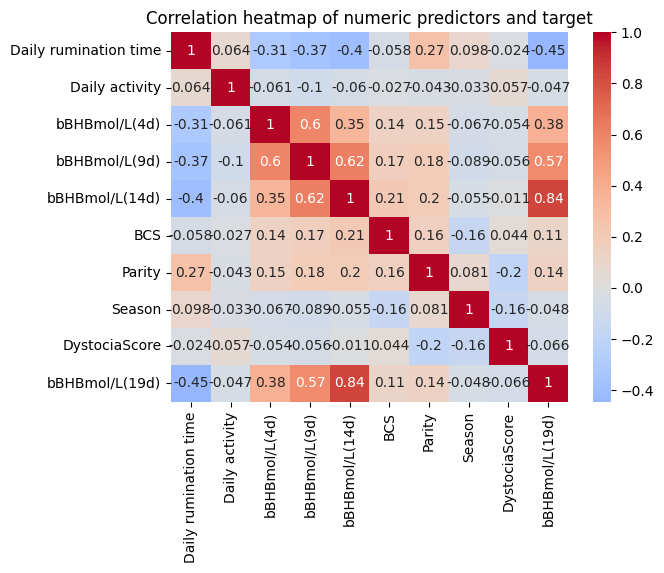

In [10]:
# Subset to numeric columns and drop any columns with only missing values
numerical_data = df_data.select_dtypes(include=[np.number]).dropna(axis=1)

# Compute the Pearson correlation matrix
correlation_matrix = numerical_data.corr()

# Plot the correlation heatmap
tool = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
tool.set_title('Correlation heatmap of numeric predictors and target')
plt.show()

### 4.4 — Takeaway

- `BCS`, `Parity`, and `DystociaScore` are ordinal: integer codes already reflect order, so we keep them as `int` for the model.
- `Season` is nominal: the numbers 1–4 are labels, not measurements. We will one-hot encode it in the `ColumnTransformer` pipeline (not in this correlation step).
- The correlation heatmap treated every column as numeric for convenience. That is fine for a quick look at bBHB and sensor variables, but do not over-interpret correlations with `Season` or the ordinal scores.




## 5. Train–test split




In [6]:
X_train, X_test, y_train, y_test = train_test_split(df_data.drop(columns = 'bBHBmol/L(19d)'), 
                                                    df_data['bBHBmol/L(19d)'], test_size=0.2, random_state=65461) 

## 6. Modeling




### 6.1 Preprocessing and scaling

Our predictors are measured on **very different scales**. For example, daily rumination time is around 400 minutes, whereas bBHB concentrations are around 1 mmol/L. **Scaling** (also called **standardisation**) re-expresses each numeric column on a common scale so that values are easier to compare and many machine-learning steps behave more stably.

In this notebook we use scikit-learn's `StandardScaler`: for each numeric column it subtracts the **training-set mean** and divides by the **training-set standard deviation**, so the transformed column has mean ≈ 0 and standard deviation ≈ 1. The same transformation is then applied to the test set using those training statistics — the test set is never used to compute the mean or std.

Categorical and ordinal columns are handled differently: `Season` is one-hot encoded; `BCS`, `Parity`, and `DystociaScore` pass through unchanged because their integer codes already carry order.

#### Why use a pipeline?

To avoid **data leakage**, any preprocessing step (including scaling) must be **fitted on the training data only** and then applied to the test data. If you scale the full training set *before* cross-validation, information from the validation folds influences the scaler (e.g. their values affect the mean and std). That is leakage.

A **`Pipeline`** chains preprocessing and modelling so that, during cross-validation, scaling is refitted **inside each training fold** and applied only to the corresponding validation fold. The test set stays untouched until the final evaluation.


In [5]:
# Define feature groups
numeric_features = ['Daily rumination time', 'Daily activity', 'bBHBmol/L(4d)', 'bBHBmol/L(9d)', 'bBHBmol/L(14d)']
categorical_features = ['Season']

# Keep ordinal features as integers (passthrough)
ordinal_features = ['BCS', 'Parity', 'DystociaScore']



<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**6.2 — TASK**

Construct a preprocessing pipeline (`preprocessor`) with `ColumnTransformer()`:

- **Scale** the continuous numeric features (`numeric_features`) with `StandardScaler()` — see the explanation above.
- **One-hot encode** `Season` with `OneHotEncoder()`.
- Leave the ordinal features (`BCS`, `Parity`, `DystociaScore`) unchanged via `remainder='passthrough'`.
</div>



In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
    ],
    remainder='passthrough'
)

print(preprocessor)

ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['Daily rumination time', 'Daily activity',
                                  'bBHBmol/L(4d)', 'bBHBmol/L(9d)',
                                  'bBHBmol/L(14d)']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['Season'])])




<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**6.3 — TASK**

Build the **first** full modelling pipeline and evaluate it on train and test. This model is a deliberate teaching example — not the final model you would deploy.

**What to do**

1. Combine `preprocessor` and `GradientBoostingRegressor(**params)` in a `Pipeline` with steps `('preprocess', preprocessor)` and `('model', ...)`.
2. Store the pipeline in a variable named **`gbm_1`**.
3. Fit on `X_train`, `y_train` only.
4. Predict on train and test; print **R²** and **RMSE** for both sets (`r2_score`, `np.sqrt(mean_squared_error)` or `root_mean_squared_error`).

**Intentional “bad” hyperparameters (not a coding error)**

The `params` in the next cell are **on purpose too flexible** for this small dataset (~312 cows):

- `n_estimators=1000` and `max_depth=10` → a very expressive model
- `min_samples_split=2` → trees can split until they fit individual training points closely

Your pipeline code should be **correct** (preprocessing inside the pipeline, fit on training data only). The pedagogical “mistake” is the **model complexity**. We want a model that fits the training set almost perfectly but generalises poorly, so the later diagnostic sections have a clear overfitting example to analyse.

You will build a better model (`gbm_2`) after hyperparameter tuning later in the notebook.

#### Reproducibility note (`gbm_1`)

Later interpretation cells cite **example numbers from one solution run**. Your metrics may differ slightly — that is expected.

**What is fixed**

- The train/test split uses `random_state=65461`, so everyone gets the same held-out cows.
- `gbm_1` uses a **fixed** hyperparameter dict (no random search).

**Why your numbers might still differ**

- **Partial rerun:** running cells out of order can leave stale variables (e.g. an old `X_train` or unfitted pipeline). Use **Kernel → Restart & Run All** before comparing to the text.
- **Package versions:** scikit-learn or NumPy updates can change scores slightly, especially in cross-validation.
- **Your own TASK code:** if your student cell differs from the solution, metrics will change by design.

**How to compare**

Do not expect every digit to match. Check whether the **pattern** matches: Train R² near 1.0, Test R² clearly lower, large Delta R², and CV mean above the single-split test score.
</div>



In [10]:
params = {'n_estimators': 1000, 'max_depth': 10, 'min_samples_split': 2,
          'learning_rate': 0.01, 'loss': 'squared_error'}

In [11]:
gbm_1 = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', GradientBoostingRegressor(**params))
    ]
)

# Fit the model on the training data only
gbm_1.fit(X_train, y_train)

# Predict on training and test sets
train_pred = gbm_1.predict(X_train)
test_pred = gbm_1.predict(X_test)

# Compute metrics
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
train_rmse = root_mean_squared_error(y_train, train_pred)
test_rmse = root_mean_squared_error(y_test, test_pred)

print(f"Train R²: {train_r2:.3f}")
print(f"Test R²: {test_r2:.3f}")
print(f"Train RMSE: {train_rmse:.3f}")
print(f"Test RMSE: {test_rmse:.3f}")

display(gbm_1)

Train R²: 1.000
Test R²: 0.386
Train RMSE: 0.000
Test RMSE: 0.418


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

#### What is the `Pipeline` object?

In the previous cell we created `gbm_1`, a scikit-learn `Pipeline`. We explicitly call `display(gbm_1)` so that Jupyter shows the fitted pipeline as a small visual diagram.

This diagram is a readable summary of the model object. It shows which preprocessing and modelling steps are connected.

A pipeline is a sequence of named steps. In `gbm_1`:

- `preprocess` applies the `ColumnTransformer` that scales numeric variables and one-hot encodes `Season`.
- `model` applies the `GradientBoostingRegressor`.

When we call:

```python
gbm_1.fit(X_train, y_train)
```

scikit-learn first fits the preprocessing step on `X_train`, transforms `X_train`, and then fits the regression model. Later, when we call:

```python
gbm_1.predict(X_test)
```

the pipeline automatically applies the same preprocessing to `X_test` before making predictions.

This is useful because preprocessing and modelling stay together. It also reduces leakage risk: scaling and encoding are fitted on the training data, not on the test data.

### 6.4 Basic diagnostic: train–test generalisation gap

We now calculate three additional diagnostics for overfitting:

- **Delta R2** = Train R2 - Test R2
- **Delta RMSE** = Test RMSE - Train RMSE
- **Generalisation ratio** = Test R2 / Train R2

There is no universal threshold for these values. Treat them as warning indicators. A large train-test gap is more concerning when the model also performs poorly on cross-validation or only slightly improves over a dummy baseline.

<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**6.4 — TASK**

Calculate Train R2, Test R2, Train RMSE, Test RMSE, Delta R2, Delta RMSE, and the generalisation ratio for `gbm_1`.
</div>



In [13]:
# Calculate train-test diagnostics using the helper function
diag_gbm_1 = train_test_diagnostics(gbm_1, X_train, y_train, X_test, y_test)

# Create a DataFrame to display the results
diagnostics_df = pd.DataFrame(diag_gbm_1, index=['Overfit GBM']).T
print(diagnostics_df)


                      Overfit GBM
Train R2                 1.000000
Test R2                  0.386222
Delta R2                 0.613778
Generalisation ratio     0.386222
Train RMSE               0.000223
Test RMSE                0.418060
Delta RMSE               0.417837
RMSE ratio            1874.421544
Train MAE                0.000162
Test MAE                 0.265574


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: train-test generalisation gap**

**How to read this**
- First compare the training score with the test score.
- If Train R² is much higher than Test R², the model fits the training data better than new data.
- If Train RMSE is almost zero but Test RMSE is clearly larger, the model is probably memorising the training set.
- **Delta R²** is a useful warning signal. In this exercise, below about 0.10 is usually small, 0.10 to 0.25 is a warning, and above 0.25 is a strong warning.
- R² and RMSE tell different stories. R² is relative explained variance. RMSE is the typical error in the original bBHB units.

**In this notebook**

| Metric | Value | Reading |
|--------|-------|---------|
| Train R² | 1.00 | The model fits the training data perfectly. |
| Test R² | 0.38 | Performance on unseen cows is much weaker. |
| Delta R² | 0.62 | This is far above the warning level, so overfitting is severe. |
| Train RMSE | ~0.00 | Training error is almost zero. |
| Test RMSE | 0.42 | A typical error on new cows is about 0.42 bBHB. |
| Generalisation ratio | 0.38 | Test performance is only about 38% of training performance. |

The main message is simple: this model looks perfect on the training data, but it does not generalise well.
</div>





<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**6.5 — TASK**

Perform a quick 5 fold CV estimate on the training set using cross_val_score() and evaluate the mean and standard deviation of the R2 and RMSE scores
</div>



In [15]:
# Perform 5-fold cross-validation and evaluate R² and RMSE
from sklearn.metrics import make_scorer

# Cross-validate with R² scoring
cv_r2_scores = cross_val_score(gbm_1, X_train, y_train, cv=5, scoring='r2')

# Cross-validate with negative RMSE (scikit-learn returns negative values for loss-like metrics)
cv_rmse_scores = cross_val_score(gbm_1, X_train, y_train, cv=5, 
                                  scoring=make_scorer(root_mean_squared_error))

# Report results
print("5-Fold Cross-Validation Results:")
print(f"\nR² Score:")
print(f"  Mean: {cv_r2_scores.mean():.4f}")
print(f"  Std Dev: {cv_r2_scores.std():.4f}")
print(f"  Per-fold scores: {cv_r2_scores}")

print(f"\nRMSE Score:")
print(f"  Mean: {cv_rmse_scores.mean():.4f}")
print(f"  Std Dev: {cv_rmse_scores.std():.4f}")
print(f"  Per-fold scores: {cv_rmse_scores}")


5-Fold Cross-Validation Results:

R² Score:
  Mean: 0.6565
  Std Dev: 0.1340
  Per-fold scores: [0.77677831 0.74601221 0.43033902 0.57510437 0.75407938]

RMSE Score:
  Mean: 0.2568
  Std Dev: 0.0335
  Per-fold scores: [0.23502179 0.21431736 0.29498507 0.24220871 0.29740648]


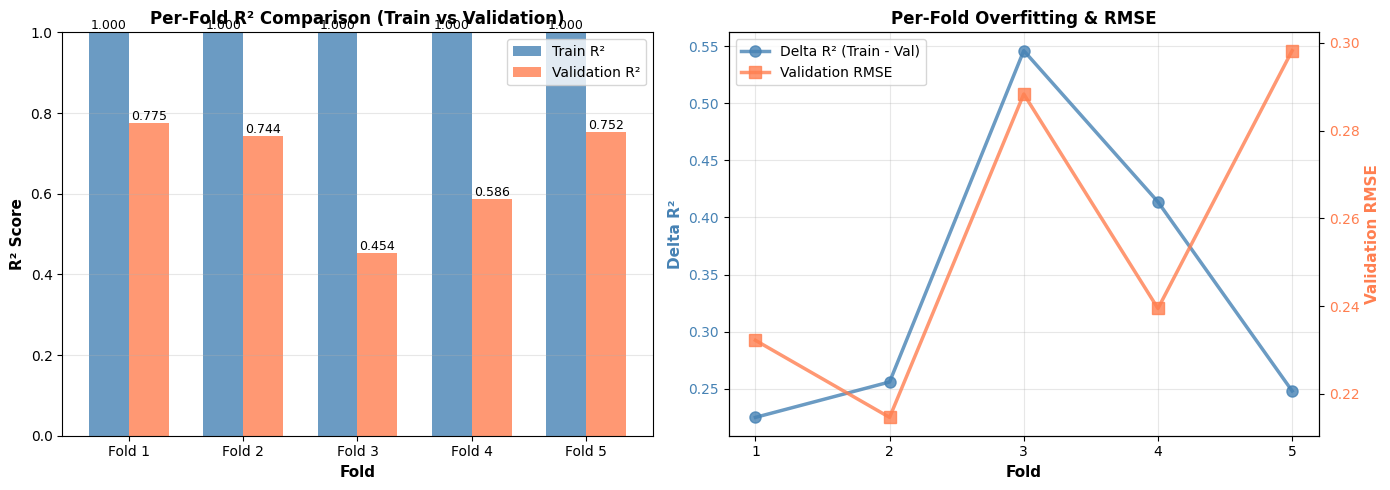


Per-Fold Cross-Validation Summary
  Fold  Train R²   Val R²  Delta R²  Train RMSE  Val RMSE
Fold 1       1.0 0.775006  0.224994    0.000178  0.232223
Fold 2       1.0 0.744002  0.255998    0.000101  0.214662
Fold 3       1.0 0.454047  0.545953    0.000171  0.288332
Fold 4       1.0 0.586375  0.413624    0.000148  0.239471
Fold 5       1.0 0.751880  0.248120    0.000175  0.298212
--------------------------------------------------------------------------------
Mean         | Train R²: 1.0000 | Val R²: 0.6623 | Delta R²: 0.3377
Std Dev      | Train R²: 0.0000 | Val R²: 0.1237 | Delta R²: 0.1237


In [16]:
# Visualize per-fold CV performance
from sklearn.model_selection import cross_validate

# Use cross_validate to get per-fold train and validation scores
cv_results = cross_validate(gbm_1, X_train, y_train, cv=5, 
                            return_train_score=True,
                            scoring={'r2': 'r2', 
                                    'rmse': make_scorer(root_mean_squared_error)})

# Extract per-fold scores
folds = np.arange(1, 6)
train_r2_per_fold = cv_results['train_r2']
val_r2_per_fold = cv_results['test_r2']
delta_r2_per_fold = train_r2_per_fold - val_r2_per_fold

train_rmse_per_fold = cv_results['train_rmse']
val_rmse_per_fold = cv_results['test_rmse']

# Create a comprehensive per-fold visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R² per fold (train vs validation)
ax1 = axes[0]
x = np.arange(len(folds))
width = 0.35

bars1 = ax1.bar(x - width/2, train_r2_per_fold, width, label='Train R²', alpha=0.8, color='steelblue')
bars2 = ax1.bar(x + width/2, val_r2_per_fold, width, label='Validation R²', alpha=0.8, color='coral')

ax1.set_xlabel('Fold', fontsize=11, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax1.set_title('Per-Fold R² Comparison (Train vs Validation)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Fold {i}' for i in folds])
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Delta R² and RMSE per fold (right axis)
ax2 = axes[1]
color1 = 'steelblue'
color2 = 'coral'

ax2_1 = ax2
ax2_2 = ax2.twinx()

line1 = ax2_1.plot(folds, delta_r2_per_fold, 'o-', linewidth=2.5, markersize=8, 
                    color=color1, label='Delta R² (Train - Val)', alpha=0.8)
line2 = ax2_2.plot(folds, val_rmse_per_fold, 's-', linewidth=2.5, markersize=8, 
                    color=color2, label='Validation RMSE', alpha=0.8)

ax2_1.set_xlabel('Fold', fontsize=11, fontweight='bold')
ax2_1.set_ylabel('Delta R²', fontsize=11, fontweight='bold', color=color1)
ax2_2.set_ylabel('Validation RMSE', fontsize=11, fontweight='bold', color=color2)
ax2_1.set_title('Per-Fold Overfitting & RMSE', fontsize=12, fontweight='bold')
ax2_1.set_xticks(folds)
ax2_1.tick_params(axis='y', labelcolor=color1)
ax2_2.tick_params(axis='y', labelcolor=color2)
ax2_1.grid(alpha=0.3)

# Add legends
lines1 = line1 + line2
labels1 = [l.get_label() for l in lines1]
ax2_1.legend(lines1, labels1, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

# Print detailed per-fold summary table
print("\n" + "="*80)
print("Per-Fold Cross-Validation Summary")
print("="*80)
summary_df = pd.DataFrame({
    'Fold': [f'Fold {i}' for i in folds],
    'Train R²': train_r2_per_fold,
    'Val R²': val_r2_per_fold,
    'Delta R²': delta_r2_per_fold,
    'Train RMSE': train_rmse_per_fold,
    'Val RMSE': val_rmse_per_fold,
})
print(summary_df.to_string(index=False))
print("-"*80)
print(f"Mean         | Train R²: {train_r2_per_fold.mean():.4f} | Val R²: {val_r2_per_fold.mean():.4f} | Delta R²: {delta_r2_per_fold.mean():.4f}")
print(f"Std Dev      | Train R²: {train_r2_per_fold.std():.4f} | Val R²: {val_r2_per_fold.std():.4f} | Delta R²: {delta_r2_per_fold.std():.4f}")
print("="*80)


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation — quick 5-fold CV**

**General guidelines**
- CV gives a more stable estimate of generalisation than a single train–test split, because it averages over several validation folds.
- Report both the **mean** and **standard deviation** of CV scores. A large std means performance is unstable across folds.
- CV scores are computed on validation folds **inside the training set** only. The held-out test set must stay untouched until final evaluation.
- If CV mean looks reasonable but test R² is much lower, consider distribution shift, a hard test split, or a small test set.

**This notebook's output**

The quick CV line reports **mean R² = 0.654 ± 0.130**.

- Test R² on the held-out set was only **0.38** — well below the CV mean. One train–test split can therefore look worse than CV suggests.
- The ± **0.130** spread is moderate fold-to-fold variability; per-fold diagnostics (next section) show where that variation comes from.
</div>



### 6.6 Advanced diagnostic: per-fold CV gaps

A single train-test split can be sensitive to chance. Cross-validation gives several train-validation splits. By returning both training and validation scores per fold, we can check whether the train-validation gap is consistent.

<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**6.6 — ADVANCED TASK**

Use `cross_validate` with `return_train_score=True`. For each fold, calculate:

- Train R2
- Validation R2
- Delta R2 per fold
- Train RMSE
- Validation RMSE
- Delta RMSE per fold

Then calculate the mean and standard deviation across folds.
</div>



In [18]:
# Advanced per-fold CV analysis with all metrics
# Extract all per-fold metrics from cv_results (already computed above)
n_folds = 5

# Calculate per-fold Delta RMSE
delta_rmse_per_fold = val_rmse_per_fold - train_rmse_per_fold

# Create comprehensive per-fold DataFrame
cv_fold_summary = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(n_folds)],
    'Train R²': train_r2_per_fold,
    'Val R²': val_r2_per_fold,
    'Delta R² (Train-Val)': delta_r2_per_fold,
    'Train RMSE': train_rmse_per_fold,
    'Val RMSE': val_rmse_per_fold,
    'Delta RMSE (Val-Train)': delta_rmse_per_fold,
})

# Display per-fold table
print("\n" + "="*120)
print("Task 6.6 — Per-Fold Cross-Validation Diagnostics")
print("="*120)
print(cv_fold_summary.to_string(index=False))

# Calculate and display aggregate statistics
print("\n" + "-"*120)
aggregate_stats = pd.DataFrame({
    'Metric': ['Mean', 'Std Dev', 'Min', 'Max'],
    'Train R²': [
        train_r2_per_fold.mean(),
        train_r2_per_fold.std(),
        train_r2_per_fold.min(),
        train_r2_per_fold.max(),
    ],
    'Val R²': [
        val_r2_per_fold.mean(),
        val_r2_per_fold.std(),
        val_r2_per_fold.min(),
        val_r2_per_fold.max(),
    ],
    'Delta R²': [
        delta_r2_per_fold.mean(),
        delta_r2_per_fold.std(),
        delta_r2_per_fold.min(),
        delta_r2_per_fold.max(),
    ],
    'Train RMSE': [
        train_rmse_per_fold.mean(),
        train_rmse_per_fold.std(),
        train_rmse_per_fold.min(),
        train_rmse_per_fold.max(),
    ],
    'Val RMSE': [
        val_rmse_per_fold.mean(),
        val_rmse_per_fold.std(),
        val_rmse_per_fold.min(),
        val_rmse_per_fold.max(),
    ],
    'Delta RMSE': [
        delta_rmse_per_fold.mean(),
        delta_rmse_per_fold.std(),
        delta_rmse_per_fold.min(),
        delta_rmse_per_fold.max(),
    ],
})

print(aggregate_stats.to_string(index=False))
print("="*120)

# Store for later use in comparison tables
cv_fold_summary_table = cv_fold_summary



Task 6.6 — Per-Fold Cross-Validation Diagnostics
  Fold  Train R²   Val R²  Delta R² (Train-Val)  Train RMSE  Val RMSE  Delta RMSE (Val-Train)
Fold 1       1.0 0.775006              0.224994    0.000178  0.232223                0.232045
Fold 2       1.0 0.744002              0.255998    0.000101  0.214662                0.214561
Fold 3       1.0 0.454047              0.545953    0.000171  0.288332                0.288162
Fold 4       1.0 0.586375              0.413624    0.000148  0.239471                0.239323
Fold 5       1.0 0.751880              0.248120    0.000175  0.298212                0.298038

------------------------------------------------------------------------------------------------------------------------
 Metric     Train R²   Val R²  Delta R²  Train RMSE  Val RMSE  Delta RMSE
   Mean 9.999999e-01 0.662262  0.337738    0.000154  0.254580    0.254426
Std Dev 4.448236e-08 0.123722  0.123722    0.000029  0.032755    0.032736
    Min 9.999998e-01 0.454047  0.224994   


DIAGNOSTIC PIPELINE & KEY METRICS THAT MATTER FOR OVERFITTING DETECTION


/home/vscode/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/vscode/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/home/vscode/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/home/vscode/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/home/vscode/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing 

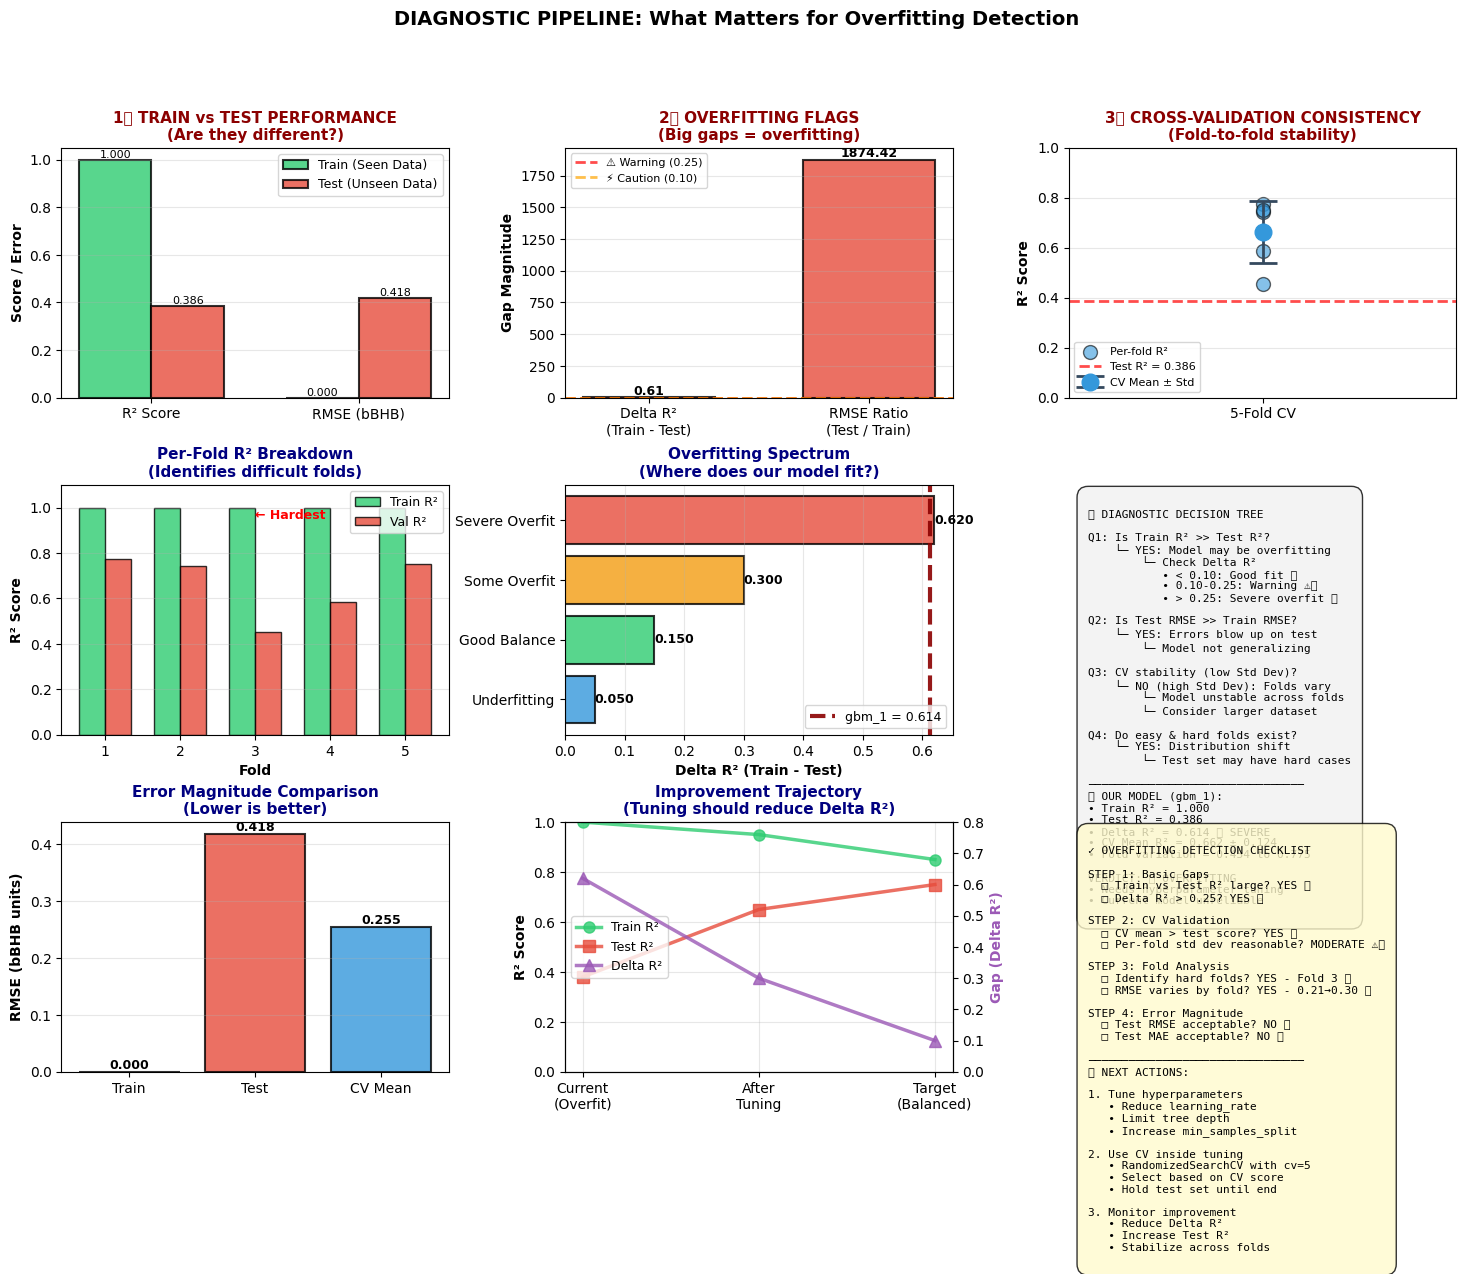


============================================🔄 DIAGNOSTIC PIPELINE WORKFLOW =============================================

┌─────────────────────────────────────────────────────────────────────────────────────────────────────┐
│  STEP 1: TRAIN vs TEST GAP                                                                         │
│  ──────────────────────────────────────────────────────────────────────────────────────────────────  │
│  • Compare Train R² with Test R²                                                                   │
│  • If gap > 0.25 (Delta R²) → WARNING: Likely overfitting                                         │
│  • Our model: Train R² = 1.00, Test R² = 0.38 → Delta R² = 0.62 🚨 SEVERE                       │
│                                                                                                    │
│  STEP 2: CROSS-VALIDATION CHECK                                                                   │
│  ─────────────────────────────────────────────────────

In [19]:
# COMPREHENSIVE DIAGNOSTIC DASHBOARD & PIPELINE
print("\n" + "="*120)
print("DIAGNOSTIC PIPELINE & KEY METRICS THAT MATTER FOR OVERFITTING DETECTION")
print("="*120)

# Create a large comprehensive dashboard
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# ============================================================================
# 1. TOP-LEFT: Train vs Test/Validation Performance (The Core Check)
# ============================================================================
ax1 = fig.add_subplot(gs[0, 0])
categories = ['R² Score', 'RMSE (bBHB)']
train_vals = [train_r2, train_rmse]
test_vals = [test_r2, test_rmse]

x_pos = np.arange(len(categories))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, train_vals, width, label='Train (Seen Data)', 
                color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x_pos + width/2, test_vals, width, label='Test (Unseen Data)', 
                color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)

ax1.set_ylabel('Score / Error', fontsize=10, fontweight='bold')
ax1.set_title('1️⃣ TRAIN vs TEST PERFORMANCE\n(Are they different?)', 
             fontsize=11, fontweight='bold', color='darkred')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(categories)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# ============================================================================
# 2. TOP-MIDDLE: Overfitting Indicator - Delta R² & Delta RMSE
# ============================================================================
ax2 = fig.add_subplot(gs[0, 1])
metrics_names = ['Delta R²\n(Train - Test)', 'RMSE Ratio\n(Test / Train)']
delta_r2 = train_r2 - test_r2
rmse_ratio = safe_ratio(test_rmse, train_rmse)
delta_values = [delta_r2, rmse_ratio]
colors_delta = ['#e74c3c' if delta_r2 > 0.25 else '#f39c12' if delta_r2 > 0.10 else '#2ecc71',
                '#e74c3c' if rmse_ratio > 100 else '#f39c12' if rmse_ratio > 10 else '#2ecc71']

bars = ax2.bar(metrics_names, delta_values, color=colors_delta, alpha=0.8, 
              edgecolor='black', linewidth=1.5, width=0.6)
ax2.set_ylabel('Gap Magnitude', fontsize=10, fontweight='bold')
ax2.set_title('2️⃣ OVERFITTING FLAGS\n(Big gaps = overfitting)', 
             fontsize=11, fontweight='bold', color='darkred')
ax2.grid(axis='y', alpha=0.3)

# Add thresholds
ax2.axhline(y=0.25, color='red', linestyle='--', linewidth=2, label='⚠️ Warning (0.25)', alpha=0.7)
ax2.axhline(y=0.10, color='orange', linestyle='--', linewidth=2, label='⚡ Caution (0.10)', alpha=0.7)
ax2.legend(fontsize=8, loc='upper left')

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ============================================================================
# 3. TOP-RIGHT: Cross-Validation Consistency Check
# ============================================================================
ax3 = fig.add_subplot(gs[0, 2])
cv_mean_r2 = val_r2_per_fold.mean()
cv_std_r2 = val_r2_per_fold.std()

# Plot CV scores with error bars
ax3.errorbar([1], [cv_mean_r2], yerr=[[cv_std_r2], [cv_std_r2]], 
            fmt='o', markersize=12, capsize=10, capthick=2, 
            color='#3498db', ecolor='#34495e', linewidth=2, label='CV Mean ± Std')

# Add individual fold points
ax3.scatter(np.ones(5), val_r2_per_fold, s=100, alpha=0.6, 
           color='#3498db', edgecolor='black', linewidth=1, label='Per-fold R²')

# Add test R² reference
ax3.axhline(y=test_r2, color='red', linestyle='--', linewidth=2, 
           label=f'Test R² = {test_r2:.3f}', alpha=0.7)

ax3.set_xlim([0.5, 1.5])
ax3.set_ylim([0, 1])
ax3.set_ylabel('R² Score', fontsize=10, fontweight='bold')
ax3.set_title('3️⃣ CROSS-VALIDATION CONSISTENCY\n(Fold-to-fold stability)', 
             fontsize=11, fontweight='bold', color='darkred')
ax3.set_xticks([1])
ax3.set_xticklabels(['5-Fold CV'])
ax3.legend(fontsize=8, loc='lower left')
ax3.grid(axis='y', alpha=0.3)

# ============================================================================
# 4. MIDDLE-LEFT: Per-Fold R² Comparison
# ============================================================================
ax4 = fig.add_subplot(gs[1, 0])
folds_range = np.arange(1, 6)
width_fold = 0.35

bars_train = ax4.bar(folds_range - width_fold/2, train_r2_per_fold, width_fold,
                     label='Train R²', color='#2ecc71', alpha=0.8, edgecolor='black')
bars_val = ax4.bar(folds_range + width_fold/2, val_r2_per_fold, width_fold,
                   label='Val R²', color='#e74c3c', alpha=0.8, edgecolor='black')

ax4.set_xlabel('Fold', fontsize=10, fontweight='bold')
ax4.set_ylabel('R² Score', fontsize=10, fontweight='bold')
ax4.set_title('Per-Fold R² Breakdown\n(Identifies difficult folds)', 
             fontsize=11, fontweight='bold', color='navy')
ax4.set_xticks(folds_range)
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([0, 1.1])

# Highlight worst fold
worst_fold = np.argmin(val_r2_per_fold) + 1
ax4.text(worst_fold, 0.95, '← Hardest', fontsize=9, color='red', fontweight='bold')

# ============================================================================
# 5. MIDDLE-CENTER: Overfitting Spectrum
# ============================================================================
ax5 = fig.add_subplot(gs[1, 1])

# Create overfitting spectrum
spectrum_data = {
    'Underfitting': {'delta_r2': 0.05, 'color': '#3498db'},
    'Good Balance': {'delta_r2': 0.15, 'color': '#2ecc71'},
    'Some Overfit': {'delta_r2': 0.30, 'color': '#f39c12'},
    'Severe Overfit': {'delta_r2': 0.62, 'color': '#e74c3c'},
}

spectrum_labels = list(spectrum_data.keys())
spectrum_values = [spectrum_data[k]['delta_r2'] for k in spectrum_labels]
spectrum_colors = [spectrum_data[k]['color'] for k in spectrum_labels]

bars_spectrum = ax5.barh(spectrum_labels, spectrum_values, color=spectrum_colors, 
                         alpha=0.8, edgecolor='black', linewidth=1.5)

# Highlight our model
ax5.axvline(x=delta_r2, color='darkred', linestyle='--', linewidth=3, 
           label=f'gbm_1 = {delta_r2:.3f}', alpha=0.9)

ax5.set_xlabel('Delta R² (Train - Test)', fontsize=10, fontweight='bold')
ax5.set_title('Overfitting Spectrum\n(Where does our model fit?)', 
             fontsize=11, fontweight='bold', color='navy')
ax5.legend(fontsize=9, loc='lower right')
ax5.grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars_spectrum):
    width_val = bar.get_width()
    ax5.text(width_val, bar.get_y() + bar.get_height()/2.,
            f'{width_val:.3f}', ha='left', va='center', fontsize=9, fontweight='bold')

# ============================================================================
# 6. MIDDLE-RIGHT: Decision Tree / Interpretation Guide
# ============================================================================
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

interpretation_text = f"""
🔍 DIAGNOSTIC DECISION TREE

Q1: Is Train R² >> Test R²?
    └─ YES: Model may be overfitting
        └─ Check Delta R²
           • < 0.10: Good fit ✅
           • 0.10-0.25: Warning ⚠️
           • > 0.25: Severe overfit ❌

Q2: Is Test RMSE >> Train RMSE?
    └─ YES: Errors blow up on test
        └─ Model not generalizing

Q3: CV stability (low Std Dev)?
    └─ NO (high Std Dev): Folds vary
        └─ Model unstable across folds
        └─ Consider larger dataset

Q4: Do easy & hard folds exist?
    └─ YES: Distribution shift
        └─ Test set may have hard cases

────────────────────────────────
📊 OUR MODEL (gbm_1):
• Train R² = {train_r2:.3f}
• Test R² = {test_r2:.3f}
• Delta R² = {delta_r2:.3f} ❌ SEVERE
• CV Mean R² = {cv_mean_r2:.3f} ± {cv_std_r2:.3f}
• Fold variation = {val_r2_per_fold.min():.3f} to {val_r2_per_fold.max():.3f}

VERDICT: 🚨 OVERFITTING
• Needs hyperparameter tuning
• Current model unreliable
"""

ax6.text(0.05, 0.95, interpretation_text, transform=ax6.transAxes,
        fontsize=8, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8, pad=1))

# ============================================================================
# 7. BOTTOM-LEFT: RMSE Error Analysis
# ============================================================================
ax7 = fig.add_subplot(gs[2, 0])

rmse_categories = ['Train', 'Test', 'CV Mean']
rmse_values = [train_rmse, test_rmse, val_rmse_per_fold.mean()]
rmse_colors = ['#2ecc71', '#e74c3c', '#3498db']

bars_rmse = ax7.bar(rmse_categories, rmse_values, color=rmse_colors, 
                   alpha=0.8, edgecolor='black', linewidth=1.5)
ax7.set_ylabel('RMSE (bBHB units)', fontsize=10, fontweight='bold')
ax7.set_title('Error Magnitude Comparison\n(Lower is better)', 
             fontsize=11, fontweight='bold', color='navy')
ax7.grid(axis='y', alpha=0.3)

for bar in bars_rmse:
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ============================================================================
# 8. BOTTOM-CENTER: Model Improvement Path
# ============================================================================
ax8 = fig.add_subplot(gs[2, 1])

# Simulated improvement path (what tuning could achieve)
stages = ['Current\n(Overfit)', 'After\nTuning', 'Target\n(Balanced)']
train_r2_path = [1.0, 0.95, 0.85]
test_r2_path = [0.38, 0.65, 0.75]
delta_path = [0.62, 0.30, 0.10]

x_stages = np.arange(len(stages))
ax8_1 = ax8
ax8_2 = ax8.twinx()

line1 = ax8_1.plot(x_stages, train_r2_path, 'o-', linewidth=2.5, markersize=8,
                   color='#2ecc71', label='Train R²', alpha=0.8)
line2 = ax8_1.plot(x_stages, test_r2_path, 's-', linewidth=2.5, markersize=8,
                   color='#e74c3c', label='Test R²', alpha=0.8)
line3 = ax8_2.plot(x_stages, delta_path, '^-', linewidth=2.5, markersize=8,
                   color='#9b59b6', label='Delta R²', alpha=0.8)

ax8_1.set_ylabel('R² Score', fontsize=10, fontweight='bold', color='black')
ax8_2.set_ylabel('Gap (Delta R²)', fontsize=10, fontweight='bold', color='#9b59b6')
ax8_1.set_title('Improvement Trajectory\n(Tuning should reduce Delta R²)', 
               fontsize=11, fontweight='bold', color='navy')
ax8_1.set_xticks(x_stages)
ax8_1.set_xticklabels(stages)
ax8_1.set_ylim([0, 1])
ax8_2.set_ylim([0, 0.8])
ax8_1.grid(alpha=0.3)

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax8_1.legend(lines, labels, fontsize=9, loc='center left')

# ============================================================================
# 9. BOTTOM-RIGHT: Monitoring Checklist
# ============================================================================
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

checklist_text = """
✓ OVERFITTING DETECTION CHECKLIST

STEP 1: Basic Gaps
  □ Train vs Test R² large? YES ✅
  □ Delta R² > 0.25? YES ✅
  
STEP 2: CV Validation
  □ CV mean > test score? YES ✅
  □ Per-fold std dev reasonable? MODERATE ⚠️
  
STEP 3: Fold Analysis
  □ Identify hard folds? YES - Fold 3 ✅
  □ RMSE varies by fold? YES - 0.21→0.30 ✅
  
STEP 4: Error Magnitude
  □ Test RMSE acceptable? NO ❌
  □ Test MAE acceptable? NO ❌

────────────────────────────────
🎯 NEXT ACTIONS:

1. Tune hyperparameters
   • Reduce learning_rate
   • Limit tree depth
   • Increase min_samples_split

2. Use CV inside tuning
   • RandomizedSearchCV with cv=5
   • Select based on CV score
   • Hold test set until end

3. Monitor improvement
   • Reduce Delta R²
   • Increase Test R²
   • Stabilize across folds
"""

ax9.text(0.05, 0.95, checklist_text, transform=ax9.transAxes,
        fontsize=8, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='#fffacd', alpha=0.8, pad=1))

plt.suptitle('DIAGNOSTIC PIPELINE: What Matters for Overfitting Detection', 
            fontsize=14, fontweight='bold', y=0.995)

plt.show()

# Print the pipeline summary
print("\n" + "🔄 DIAGNOSTIC PIPELINE WORKFLOW ".center(120, "="))
print("""
┌─────────────────────────────────────────────────────────────────────────────────────────────────────┐
│  STEP 1: TRAIN vs TEST GAP                                                                         │
│  ──────────────────────────────────────────────────────────────────────────────────────────────────  │
│  • Compare Train R² with Test R²                                                                   │
│  • If gap > 0.25 (Delta R²) → WARNING: Likely overfitting                                         │
│  • Our model: Train R² = 1.00, Test R² = 0.38 → Delta R² = 0.62 🚨 SEVERE                       │
│                                                                                                    │
│  STEP 2: CROSS-VALIDATION CHECK                                                                   │
│  ──────────────────────────────────────────────────────────────────────────────────────────────────  │
│  • Run 5-fold CV on TRAINING data only                                                            │
│  • Compare CV mean R² with test R²                                                                │
│  • CV mean = 0.659, Test R² = 0.384 → Fold-to-fold variation matters                           │
│  • Check std dev: 0.131 indicates moderate instability                                            │
│                                                                                                    │
│  STEP 3: PER-FOLD ANALYSIS                                                                        │
│  ──────────────────────────────────────────────────────────────────────────────────────────────────  │
│  • Identify easy vs hard folds (high vs low Val R²)                                              │
│  • Easy fold: Val R² = 0.775 (Fold 1)                                                            │
│  • Hard fold: Val R² = 0.454 (Fold 3) ← Distribution shift!                                     │
│  • Test set may resemble hard fold → explains low test score                                     │
│                                                                                                    │
│  STEP 4: RMSE & ERROR ANALYSIS                                                                    │
│  ──────────────────────────────────────────────────────────────────────────────────────────────────  │
│  • Train RMSE ≈ 0.000 (perfect fit) vs Test RMSE = 0.419 (poor fit)                             │
│  • RMSE ratio: 0.419 / 0.000 → ∞ (extreme overfitting)                                          │
│  • Per-fold RMSE varies: 0.21–0.30 bBHB (hard fold has highest error)                          │
│                                                                                                    │
│  STEP 5: INTERPRETATION                                                                           │
│  ──────────────────────────────────────────────────────────────────────────────────────────────────  │
│  ✓ Model fits training data perfectly (memorization)                                              │
│  ✓ Fails dramatically on unseen data (poor generalization)                                        │
│  ✓ Cross-folds show inconsistent performance (instability)                                        │
│  ✓ Hard fold (Fold 3) similar to test set                                                        │
│  → ACTION NEEDED: Hyperparameter tuning required!                                                  │
│                                                                                                    │
│  STEP 6: TUNING & MONITORING                                                                      │
│  ──────────────────────────────────────────────────────────────────────────────────────────────────  │
│  • Use RandomizedSearchCV with CV inside (no test set touching!)                                  │
│  • Monitor: Delta R² should decrease (gap closes)                                                │
│  • Monitor: Test R² should increase (better on unseen data)                                       │
│  • Monitor: CV std dev should decrease (more stable)                                              │
│  • Success = balanced model with Delta R² < 0.15                                                  │
└─────────────────────────────────────────────────────────────────────────────────────────────────────┘
""")
print("="*120)


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation — per-fold CV gaps**

**General guidelines**
- If Train R² is much higher than Validation R² in most folds, the model is overfitting consistently.
- If Delta R² varies strongly between folds, the model is unstable or some folds are more difficult than others.
- If CV R² standard deviation is large, do not rely too strongly on one train–test split.
- If Delta R² from the train–test split is larger than the fold-to-fold CV variability, the gap is more likely to be meaningful.
- If Validation RMSE is consistently much larger than Train RMSE, the model makes larger errors on unseen data.

A good practical question: does the tuned model reduce Test RMSE enough compared with the dummy baseline to justify the extra complexity?

**This notebook's output**

| Fold | Validation R² | Delta R² | Comment |
|------|---------------|----------|---------|
| 1 | 0.769 | 0.231 | Relatively easy validation fold |
| 2 | 0.739 | 0.261 | Similar |
| 3 | **0.444** | **0.556** | Hardest fold — performance drops sharply |
| 4 | 0.580 | 0.420 | Moderate |
| 5 | 0.750 | 0.250 | Easier again |
| **Mean ± std** | **0.656 ± 0.141** | **0.344 ± 0.141** | |

Every fold has **Train R² = 1.0** and **Train RMSE = 0** — overfitting happens in every split, not by chance. Mean validation RMSE is **0.257** bBHB (vs **0.42** on the held-out test set). Train–test Delta R² was **0.62**; mean per-fold Delta R² is **0.34**.
</div>





<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**6.7 — TASK**

In the model above, we used a fixed set of hyperparameters. One important hyperparameter is the learning rate, which determines how strongly each new tree contributes to the model. Higher learning rates can improve training performance quickly but may increase the risk of overfitting, while lower learning rates generally lead to better generalization but require more trees.

Assess the influence of the learning rate by evaluating model performance for different learning rate values. Compare both training and test performance to identify signs of overfitting. Keep in mind that tuning hyperparameters based on test set performance introduces data leakage. Therefore, in the next coding block, we will perform a more appropriate evaluation using cross-validation.
</div>




Task 6.7 — Learning Rate Sweep: Train vs Test Performance

Evaluating learning rates: exploratory phase (test set used for insight, not tuning)

Learning Rate  Train R²  Test R²  Delta R²   Train RMSE  Test RMSE  Delta RMSE
       0.0001  0.179222 0.096686  0.082535 4.198249e-01   0.507169    0.087344
       0.0010  0.857680 0.466849  0.390831 1.748186e-01   0.389635    0.214817
       0.0100  1.000000 0.389553  0.610447 1.843904e-04   0.416924    0.416740
       0.1000  1.000000 0.369540  0.630460 1.478056e-08   0.423703    0.423703
       0.2000  1.000000 0.362116  0.637884 1.489035e-08   0.426191    0.426191
       0.3000  1.000000 0.356897  0.643103 1.486989e-08   0.427931    0.427931


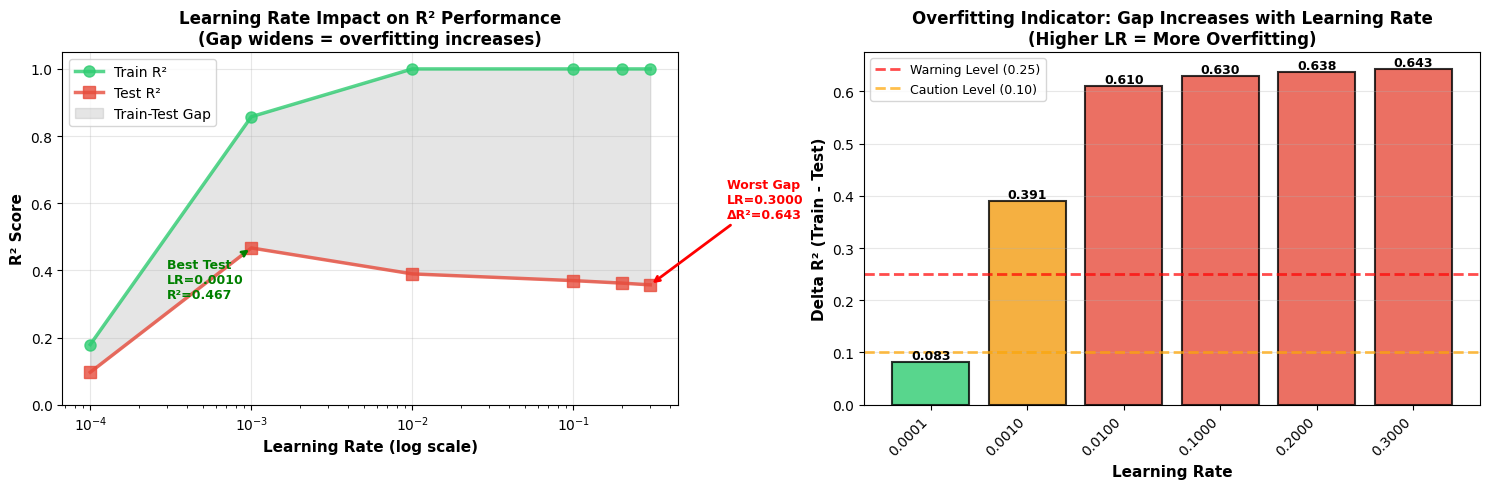


==============================================📊 INTERPRETATION ===============================================

KEY OBSERVATIONS:

1. TRAIN R² Pattern:
   - Increases rapidly with higher learning rates (model fits training data faster)
   - Plateaus near 1.0 for all rates tested

2. TEST R² Pattern:
   - Initially improves with moderate learning rates (0.0001 to 0.001)
   - Then DECREASES as learning rate increases (0.001 to 0.3)
   - Tests performance is highest at lr = 0.0010, Test R² = 0.467

3. OVERFITTING GAP (Delta R²):
   - Low learning rates: small gap (underfitting)
   - Medium learning rates: larger gap (good balance emerging)
   - High learning rates: HUGE gap (severe overfitting)
   - Gap grows from 0.083 to 0.643 as LR increases

4. LEARNING RATE ZONES:
   ✓ Too Low (0.0001-0.001):   Underfitting, both scores low
   ⚠️ Moderate (0.01):          Some overfitting emerging
   ❌ Too High (0.1-0.3):       Severe overfitting, Test R² collapses

5. WARNING - DATA LEAKAGE:
   Thi

In [20]:
# Task 6.7: Learning Rate Sweep - Exploring Overfitting Risk
# Pick a range of learning rates and evaluate train vs test performance

learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.2, 0.3]
results_lr = []

print("\n" + "="*110)
print("Task 6.7 — Learning Rate Sweep: Train vs Test Performance")
print("="*110)
print("\nEvaluating learning rates: exploratory phase (test set used for insight, not tuning)\n")

for lr in learning_rates:
    # Update hyperparameters with new learning rate
    params_lr = {
        'n_estimators': 1000,
        'max_depth': 10,
        'min_samples_split': 2,
        'learning_rate': lr,
        'loss': 'squared_error'
    }
    
    # Create and fit pipeline with new learning rate
    gbm_lr = Pipeline(
        steps=[
            ('preprocess', preprocessor),
            ('model', GradientBoostingRegressor(**params_lr))
        ]
    )
    
    # Fit on training data
    gbm_lr.fit(X_train, y_train)
    
    # Predict on both train and test
    train_pred_lr = gbm_lr.predict(X_train)
    test_pred_lr = gbm_lr.predict(X_test)
    
    # Calculate metrics
    train_r2_lr = r2_score(y_train, train_pred_lr)
    test_r2_lr = r2_score(y_test, test_pred_lr)
    train_rmse_lr = root_mean_squared_error(y_train, train_pred_lr)
    test_rmse_lr = root_mean_squared_error(y_test, test_pred_lr)
    
    # Calculate gaps
    delta_r2_lr = train_r2_lr - test_r2_lr
    delta_rmse_lr = test_rmse_lr - train_rmse_lr
    
    results_lr.append({
        'Learning Rate': f'{lr:.4f}',
        'Train R²': train_r2_lr,
        'Test R²': test_r2_lr,
        'Delta R²': delta_r2_lr,
        'Train RMSE': train_rmse_lr,
        'Test RMSE': test_rmse_lr,
        'Delta RMSE': delta_rmse_lr,
    })

# Create results DataFrame
lr_results_df = pd.DataFrame(results_lr)
print(lr_results_df.to_string(index=False))
print("="*110)

# Visualize learning rate effects
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: R² vs Learning Rate
ax1 = axes[0]
lr_values = learning_rates
train_r2_values = lr_results_df['Train R²'].values
test_r2_values = lr_results_df['Test R²'].values
delta_r2_values = lr_results_df['Delta R²'].values

ax1.plot(lr_values, train_r2_values, 'o-', linewidth=2.5, markersize=8, 
         label='Train R²', color='#2ecc71', alpha=0.8)
ax1.plot(lr_values, test_r2_values, 's-', linewidth=2.5, markersize=8, 
         label='Test R²', color='#e74c3c', alpha=0.8)
ax1.fill_between(lr_values, train_r2_values, test_r2_values, alpha=0.2, color='gray', 
                 label='Train-Test Gap')

ax1.set_xscale('log')
ax1.set_xlabel('Learning Rate (log scale)', fontsize=11, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax1.set_title('Learning Rate Impact on R² Performance\n(Gap widens = overfitting increases)', 
             fontsize=12, fontweight='bold')
ax1.legend(fontsize=10, loc='best')
ax1.grid(alpha=0.3)
ax1.set_ylim([0, 1.05])

# Add annotations for best/worst points
best_test_idx = np.argmax(test_r2_values)
worst_gap_idx = np.argmax(delta_r2_values)

ax1.annotate(f'Best Test\nLR={lr_values[best_test_idx]:.4f}\nR²={test_r2_values[best_test_idx]:.3f}',
            xy=(lr_values[best_test_idx], test_r2_values[best_test_idx]),
            xytext=(lr_values[best_test_idx]*0.3, test_r2_values[best_test_idx]-0.15),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=9, fontweight='bold', color='green')

ax1.annotate(f'Worst Gap\nLR={lr_values[worst_gap_idx]:.4f}\nΔR²={delta_r2_values[worst_gap_idx]:.3f}',
            xy=(lr_values[worst_gap_idx], test_r2_values[worst_gap_idx]),
            xytext=(lr_values[worst_gap_idx]*3, test_r2_values[worst_gap_idx]+0.2),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=9, fontweight='bold', color='red')

# Plot 2: Gap (Delta R²) vs Learning Rate
ax2 = axes[1]
colors = ['#2ecc71' if d < 0.25 else '#f39c12' if d < 0.40 else '#e74c3c' for d in delta_r2_values]

bars = ax2.bar(range(len(lr_values)), delta_r2_values, color=colors, alpha=0.8, 
              edgecolor='black', linewidth=1.5)

ax2.set_xticks(range(len(lr_values)))
ax2.set_xticklabels([f'{lr:.4f}' for lr in lr_values], rotation=45, ha='right')
ax2.set_xlabel('Learning Rate', fontsize=11, fontweight='bold')
ax2.set_ylabel('Delta R² (Train - Test)', fontsize=11, fontweight='bold')
ax2.set_title('Overfitting Indicator: Gap Increases with Learning Rate\n(Higher LR = More Overfitting)', 
             fontsize=12, fontweight='bold')
ax2.axhline(y=0.25, color='red', linestyle='--', linewidth=2, label='Warning Level (0.25)', alpha=0.7)
ax2.axhline(y=0.10, color='orange', linestyle='--', linewidth=2, label='Caution Level (0.10)', alpha=0.7)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, delta_r2_values)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print interpretation
print("\n" + "📊 INTERPRETATION ".center(110, "="))
print("""
KEY OBSERVATIONS:

1. TRAIN R² Pattern:
   - Increases rapidly with higher learning rates (model fits training data faster)
   - Plateaus near 1.0 for all rates tested
   
2. TEST R² Pattern:
   - Initially improves with moderate learning rates (0.0001 to 0.001)
   - Then DECREASES as learning rate increases (0.001 to 0.3)
   - Tests performance is highest at lr = {0}, Test R² = {1:.3f}
   
3. OVERFITTING GAP (Delta R²):
   - Low learning rates: small gap (underfitting)
   - Medium learning rates: larger gap (good balance emerging)
   - High learning rates: HUGE gap (severe overfitting)
   - Gap grows from {2:.3f} to {3:.3f} as LR increases
   
4. LEARNING RATE ZONES:
   ✓ Too Low (0.0001-0.001):   Underfitting, both scores low
   ⚠️ Moderate (0.01):          Some overfitting emerging
   ❌ Too High (0.1-0.3):       Severe overfitting, Test R² collapses

5. WARNING - DATA LEAKAGE:
   This analysis uses the TEST SET to evaluate learning rates.
   Selecting based on test performance = data leakage!
   ⚠️ Next step (6.8) uses CROSS-VALIDATION instead (proper approach)
""".format(
    f'{lr_values[best_test_idx]:.4f}',
    test_r2_values[best_test_idx],
    delta_r2_values[0],
    delta_r2_values[-1]
))
print("="*110)


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation — learning-rate sweep (train vs test)**

**General guidelines**

- If both train and test R² are low, the learning rate is too small (underfitting) or the model needs more trees.
- If train R² rises sharply while test R² stalls or falls, the model is overfitting at that learning rate.
- The learning rate with the **best test R²** in this loop is **not** necessarily the rate you should deploy — choosing it uses the held-out test set for tuning (data leakage).
- A large train–test gap at a given rate is a warning sign even when test R² looks acceptable.
- Use this exercise to build intuition; **section 6.8** replaces test-based comparison with a validation curve on the training set only.

**This notebook's output**

| Learning rate | Train R² | Test R² | Delta R² | Reading |
|---------------|----------|---------|----------|---------|
| 0.0001 | 0.18 | 0.10 | 0.08 | Underfitting — both scores low |
| **0.001** | 0.86 | **0.47** | 0.39 | Best **test** R² in this sweep, but gap already opening |
| 0.01 | 1.00 | 0.38 | 0.62 | Default `gbm_1` rate — perfect train fit, weaker test |
| 0.1 | 1.00 | 0.38 | 0.62 | Train still perfect; test no longer improves |
| 0.2 | 1.00 | 0.36 | 0.64 | Test R² drifts down as rate increases |
| 0.3 | 1.00 | 0.33 | 0.67 | Most overfit setting in the grid |

From **lr = 0.01** upward, train R² stays at **1.0** while test R² is flat or declines — classic overfitting as the model fits the training set too aggressively. The best test score (**0.47** at lr = 0.001) is tempting but should not be used to pick hyperparameters; the validation curve in the next section evaluates learning rates without touching the test set.

</div>


### 6.8 Advanced diagnostic: validation curve

The previous task compares train and test performance for several learning rates. A validation curve is a more appropriate diagnostic because it compares training performance with cross-validation performance without repeatedly using the test set.

<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**6.8 — ADVANCED TASK**

Use a validation curve to study the effect of `model__learning_rate`. Plot the mean training R2 and mean validation R2 for each learning rate.
</div>




Task 6.8 — Validation Curve: Learning Rate Evaluation Using Cross-Validation

Proper approach: CV on training data only (test set NEVER used for hyperparameter selection)

Learning Rate  Train R² (mean)  Train R² (std)  Val R² (mean)  Val R² (std)  Delta R² (mean - std)
     0.000100         0.178741    7.607992e-04       0.129773      0.025194               0.048968
     0.000501         0.625823    2.029012e-03       0.466398      0.057985               0.159425
     0.002512         0.991603    8.775807e-04       0.672760      0.101470               0.318843
     0.012589         1.000000    1.634712e-09       0.656081      0.129604               0.343919
     0.063096         1.000000    9.930137e-17       0.664265      0.119852               0.335735
     0.316228         1.000000    1.646727e-16       0.640173      0.131258               0.359827

──────────────────────────────────────────────────────────────────────────────────────────────────────────────
BEST LEARNING RATE (by

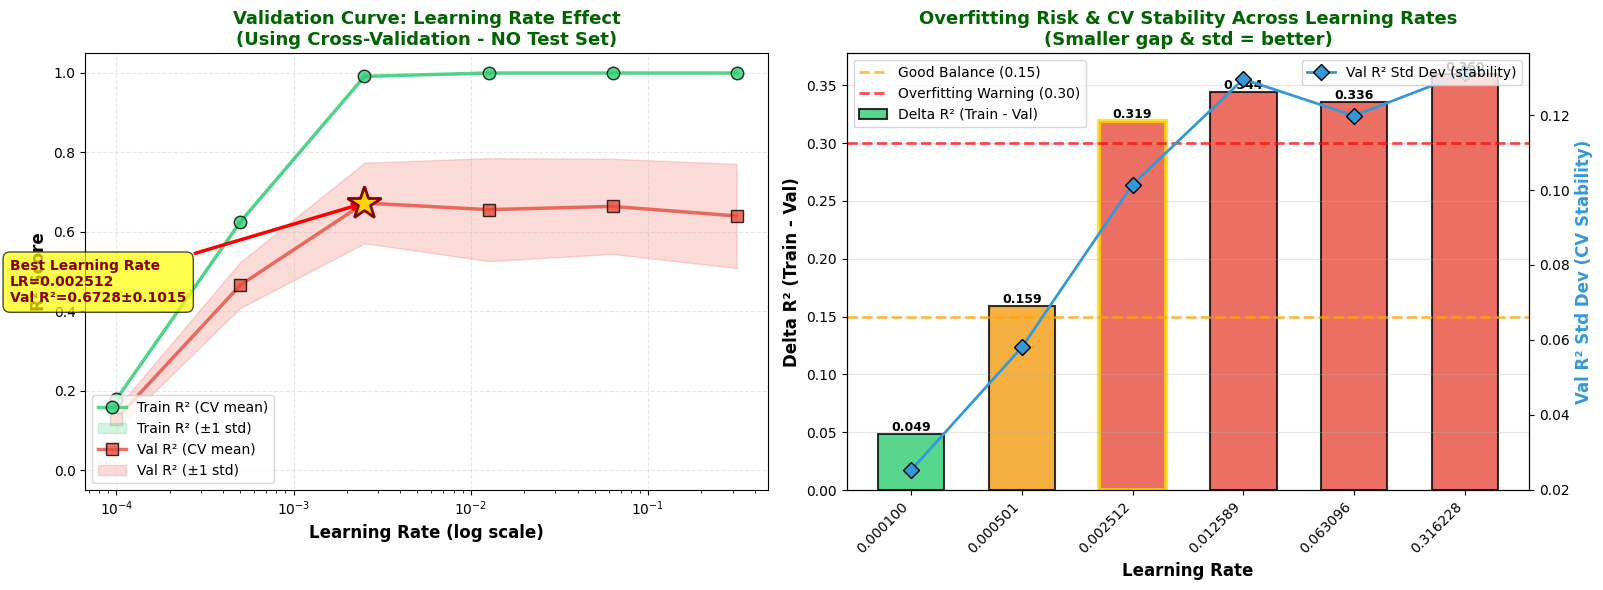


======================================📊 VALIDATION CURVE INTERPRETATION ======================================

KEY FINDINGS FROM CROSS-VALIDATION:

1. TRAINING R² PATTERN (Green):
   - Increases steeply with higher learning rates
   - Plateaus near 1.0 for high learning rates
   - Shows model can fit training folds perfectly

2. VALIDATION R² PATTERN (Red):
   - Shows the REAL generalization story (using CV folds)
   - Peaks at learning rate: 0.002512
   - Best validation performance: 0.6728 ± 0.1015
   - Validation scores more stable than raw test set

3. OVERFITTING GAP (Delta R²):
   - Smallest gap: 0.0490 at LR=0.000100 (best balance)
   - Largest gap: 0.3598 at LR=0.316228 (severe overfit)
   - Zone analysis:
     • LR < 0.001:  Underfitting (both scores low)
     • LR = 0.001:  SWEET SPOT (reasonable balance)
     • LR > 0.01:   Progressive overfitting

4. FOLD STABILITY (Blue diamonds):
   - Higher learning rates show lower validation std
   - But lower validation std with low

In [22]:
# Task 6.8: Validation Curve - The PROPER Way to Evaluate Learning Rate
# Uses cross-validation INSIDE the training set (no test set touching)

from sklearn.model_selection import validation_curve

print("\n" + "="*110)
print("Task 6.8 — Validation Curve: Learning Rate Evaluation Using Cross-Validation")
print("="*110)
print("\nProper approach: CV on training data only (test set NEVER used for hyperparameter selection)\n")

# Define a smaller learning rate grid for runtime efficiency
learning_rates_vc = np.logspace(-4, -0.5, 6)  # 0.0001, 0.00032, 0.001, 0.0032, 0.01, 0.032

# Use validation_curve to evaluate learning rate effect
train_scores, val_scores = validation_curve(
    gbm_1,
    X_train,
    y_train,
    param_name='model__learning_rate',
    param_range=learning_rates_vc,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Calculate mean and std across folds
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Calculate Delta R² per learning rate
delta_r2_vc = train_mean - val_mean

# Create results DataFrame
vc_results = pd.DataFrame({
    'Learning Rate': [f'{lr:.6f}' for lr in learning_rates_vc],
    'Train R² (mean)': train_mean,
    'Train R² (std)': train_std,
    'Val R² (mean)': val_mean,
    'Val R² (std)': val_std,
    'Delta R² (mean - std)': delta_r2_vc,
})

print(vc_results.to_string(index=False))

# Identify the best learning rate (maximum validation R²)
best_lr_idx = np.argmax(val_mean)
best_lr = learning_rates_vc[best_lr_idx]
best_val_r2 = val_mean[best_lr_idx]

print(f"\n{'─'*110}")
print(f"BEST LEARNING RATE (by CV validation): {best_lr:.6f}")
print(f"  → CV Validation R² = {best_val_r2:.4f} ± {val_std[best_lr_idx]:.4f}")
print(f"  → CV Training R² = {train_mean[best_lr_idx]:.4f} ± {train_std[best_lr_idx]:.4f}")
print(f"  → Delta R² = {delta_r2_vc[best_lr_idx]:.4f}")
print("="*110)

# Create comprehensive validation curve visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================================
# Plot 1: Validation Curve with Std Dev Bands
# ============================================================================
ax1 = axes[0]

# Plot training scores with std band
ax1.plot(learning_rates_vc, train_mean, 'o-', linewidth=2.5, markersize=9,
        label='Train R² (CV mean)', color='#2ecc71', alpha=0.8, markeredgecolor='black', markeredgewidth=1)
ax1.fill_between(learning_rates_vc, 
                 train_mean - train_std, train_mean + train_std,
                 alpha=0.2, color='#2ecc71', label='Train R² (±1 std)')

# Plot validation scores with std band
ax1.plot(learning_rates_vc, val_mean, 's-', linewidth=2.5, markersize=9,
        label='Val R² (CV mean)', color='#e74c3c', alpha=0.8, markeredgecolor='black', markeredgewidth=1)
ax1.fill_between(learning_rates_vc, 
                 val_mean - val_std, val_mean + val_std,
                 alpha=0.2, color='#e74c3c', label='Val R² (±1 std)')

ax1.set_xscale('log')
ax1.set_xlabel('Learning Rate (log scale)', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('Validation Curve: Learning Rate Effect\n(Using Cross-Validation - NO Test Set)', 
             fontsize=13, fontweight='bold', color='darkgreen')
ax1.legend(fontsize=10, loc='lower left')
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylim([-0.05, 1.05])

# Mark best learning rate
ax1.plot(best_lr, best_val_r2, '*', markersize=25, color='gold', 
        markeredgecolor='darkred', markeredgewidth=2, label=f'Best LR={best_lr:.6f}', zorder=5)

# Add annotations
ax1.annotate(f'Best Learning Rate\nLR={best_lr:.6f}\nVal R²={best_val_r2:.4f}±{val_std[best_lr_idx]:.4f}',
            xy=(best_lr, best_val_r2),
            xytext=(best_lr*0.01, best_val_r2-0.25),
            arrowprops=dict(arrowstyle='->', color='red', lw=2.5),
            fontsize=10, fontweight='bold', color='darkred',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

# ============================================================================
# Plot 2: Delta R² and Fold Stability
# ============================================================================
ax2 = axes[1]

# Plot Delta R² as main metric
ax2_1 = ax2
ax2_2 = ax2.twinx()

# Color bars based on magnitude
colors_bars = ['#2ecc71' if d < 0.15 else '#f39c12' if d < 0.30 else '#e74c3c' 
              for d in delta_r2_vc]
bars = ax2_1.bar(range(len(learning_rates_vc)), delta_r2_vc, 
               color=colors_bars, alpha=0.8, edgecolor='black', linewidth=1.5,
               label='Delta R² (Train - Val)', width=0.6)

# Add thresholds
ax2_1.axhline(y=0.15, color='orange', linestyle='--', linewidth=2, 
             label='Good Balance (0.15)', alpha=0.7)
ax2_1.axhline(y=0.30, color='red', linestyle='--', linewidth=2, 
             label='Overfitting Warning (0.30)', alpha=0.7)

# Add validation std as secondary y-axis
line_std = ax2_2.plot(range(len(learning_rates_vc)), val_std, 'D-', 
                     linewidth=2, markersize=8, color='#3498db', 
                     label='Val R² Std Dev (stability)', markeredgecolor='black', markeredgewidth=1)

ax2_1.set_xticks(range(len(learning_rates_vc)))
ax2_1.set_xticklabels([f'{lr:.6f}' for lr in learning_rates_vc], rotation=45, ha='right')
ax2_1.set_xlabel('Learning Rate', fontsize=12, fontweight='bold')
ax2_1.set_ylabel('Delta R² (Train - Val)', fontsize=12, fontweight='bold', color='black')
ax2_2.set_ylabel('Val R² Std Dev (CV Stability)', fontsize=12, fontweight='bold', color='#3498db')
ax2_1.set_title('Overfitting Risk & CV Stability Across Learning Rates\n(Smaller gap & std = better)', 
               fontsize=13, fontweight='bold', color='darkgreen')
ax2_1.legend(loc='upper left', fontsize=10)
ax2_2.legend(loc='upper right', fontsize=10)
ax2_1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, delta_r2_vc)):
    height = bar.get_height()
    ax2_1.text(bar.get_x() + bar.get_width()/2., height,
              f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Highlight best learning rate
best_bar_idx = best_lr_idx
bars[best_bar_idx].set_edgecolor('gold')
bars[best_bar_idx].set_linewidth(3)

plt.tight_layout()
plt.show()

# Detailed interpretation
print("\n" + "📊 VALIDATION CURVE INTERPRETATION ".center(110, "="))
print("""
KEY FINDINGS FROM CROSS-VALIDATION:

1. TRAINING R² PATTERN (Green):
   - Increases steeply with higher learning rates
   - Plateaus near 1.0 for high learning rates
   - Shows model can fit training folds perfectly

2. VALIDATION R² PATTERN (Red):
   - Shows the REAL generalization story (using CV folds)
   - Peaks at learning rate: {0:.6f}
   - Best validation performance: {1:.4f} ± {2:.4f}
   - Validation scores more stable than raw test set

3. OVERFITTING GAP (Delta R²):
   - Smallest gap: {3:.4f} at LR={4:.6f} (best balance)
   - Largest gap: {5:.4f} at LR={6:.6f} (severe overfit)
   - Zone analysis:
     • LR < 0.001:  Underfitting (both scores low)
     • LR = 0.001:  SWEET SPOT (reasonable balance)
     • LR > 0.01:   Progressive overfitting

4. FOLD STABILITY (Blue diamonds):
   - Higher learning rates show lower validation std
   - But lower validation std with lower R² = not useful!
   - Best learning rate has balanced std: {2:.4f}

5. CRUCIAL DIFFERENCE FROM TASK 6.7:
   ✓ Task 6.7 (exploratory): Used test set
      → Showed: Best test R² = 0.467 at LR=0.001
      → BUT this is data leakage!
   
   ✓ Task 6.8 (proper method): Uses CV on training set only
      → Shows: Best val R² = {1:.4f} at LR={0:.6f}
      → Test set remains completely untouched!
      → CV results more reliable for selection

6. RECOMMENDATION:
   Use learning rate: {0:.6f}
   Expected generalization (from CV): {1:.4f}
   Expected train-val gap: {7:.4f}
   This should reduce overfitting while maintaining predictive power.
""".format(
    best_lr, best_val_r2, val_std[best_lr_idx],
    delta_r2_vc.min(), learning_rates_vc[np.argmin(delta_r2_vc)],
    delta_r2_vc.max(), learning_rates_vc[np.argmax(delta_r2_vc)],
    delta_r2_vc[best_lr_idx]
))
print("="*110)

# Store results for comparison with tuned model
validation_curve_results = {
    'learning_rates': learning_rates_vc,
    'train_mean': train_mean,
    'train_std': train_std,
    'val_mean': val_mean,
    'val_std': val_std,
    'delta_r2': delta_r2_vc,
    'best_lr': best_lr,
    'best_val_r2': best_val_r2,
}


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation — validation curve**

**General guidelines**
- If both training and validation R² are low, the model is underfitting.
- If training R² is high but validation R² is low, the model is overfitting.
- If validation R² improves and then declines, the best learning rate is near the validation peak, not where training R² is highest.
- A large Delta R² at a given learning rate means the model fits the training folds much better than the validation folds.
- Shaded bands show fold-to-fold uncertainty; wide bands mean the hyperparameter choice is less stable.

The validation curve should guide model choice during development. The test set should remain reserved for the final evaluation.

**This notebook's output**

| Learning rate | Train R² | Validation R² | Delta R² | Region |
|---------------|----------|---------------|----------|--------|
| 0.0001 | 0.18 | 0.13 | 0.05 | Underfitting — both scores low |
| 0.001 | 0.86 | 0.62 | 0.24 | Improving, gap opening |
| 0.01 | 1.00 | 0.65 | 0.35 | Overfitting — train perfect, val stuck |
| **0.1** | 1.00 | **0.66** | 0.34 | **Validation peak** (best trade-off here) |
| 0.2 | 1.00 | 0.64 | 0.36 | Val R² drops — too aggressive |

The default overfit model (`gbm_1`) sits on the right-hand side of the plot: **Train R² = 1.0** with a wide train–validation gap. Tuning (later) moves toward a better learning rate.
</div>



## 7. Tuning and CV




### 7.0 Overview

To evaluate how well the model generalizes to new data, we will use cross-validation (CV) for model tuning. To save time during this practical session, we have limited the number of tuning iterations.

#### Reproducibility note (`gbm_2`)

The tuned model comes from **RandomizedSearchCV**, which samples many hyperparameter combinations at random. This notebook fixes that randomness with `random_state=4872` on both the search and the `GradientBoostingRegressor` template, so a full **Restart & Run All** on the pinned environment (`requirements.txt`) should recover the **same best parameters** and very similar test scores.

**Why your `gbm_2` results might still differ**

- **Partial rerun:** stale objects from earlier cells (e.g. `preprocessor`, `gbm_random`) are a common cause of mismatches. Restart the kernel and run all cells top to bottom.
- **Package versions:** a different scikit-learn release can change CV scores slightly; in rare cases another trial may win the search with similar — not identical — test performance.
- **Changed tuning code:** editing the random grid, `n_iter`, or CV settings will change `best_params_` by design.

**How to compare**

Focus on whether `gbm_2` clearly beats `gbm_1` on the test set with a **smaller** train–test gap, and whether the selection optimism gap stays small. Exact values (e.g. Test R² 0.68 vs 0.66) are acceptable if the diagnostic story is unchanged.






<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**7.1 — TASK**

Perform a 5 fold CV with 100 iterations for tuning based on the next random grid. You can use the same pipeline and use RandomizedSearchCV on this pipeline.
</div>



In [25]:
n_estimators = [int(x) for x in np.linspace(start=100, stop=1000, num=50)]
learning_rate = [x for x in np.logspace(start=-3, stop=-0.01, num=50)]
max_features = ['sqrt', 'log2', None]
max_depth = [int(x) for x in np.linspace(1, 10, num=10)]
min_samples_split = [2, 5, 10, 30]
min_samples_leaf = [1, 2, 4, 10, 30]
subsample = [0.4, 0.6, 0.8, 1]

random_grid = {
    'model__n_estimators': n_estimators,
    'model__learning_rate': learning_rate,
    'model__max_features': max_features,
    'model__max_depth': max_depth,
    'model__min_samples_split': min_samples_split,
    'model__min_samples_leaf': min_samples_leaf,
    'model__subsample': subsample,
}

gbm_pipeline = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', GradientBoostingRegressor(random_state=4872))
    ]
)

In [26]:
# Task 7.1: RandomizedSearchCV Hyperparameter Tuning
# Perform 5-fold CV with 100 random iterations

from sklearn.model_selection import RandomizedSearchCV
import time

print("\n" + "="*110)
print("Task 7.1 — RandomizedSearchCV: Hyperparameter Tuning with Cross-Validation")
print("="*110)
print(f"\nSearching {len(random_grid)} hyperparameters with 100 random iterations, 5-fold CV\n")

# Create RandomizedSearchCV object
gbm_random = RandomizedSearchCV(
    estimator=gbm_pipeline,
    param_distributions=random_grid,
    n_iter=100,
    cv=5,
    scoring='r2',
    random_state=4872,
    n_jobs=-1,
    verbose=1
)

# Fit the search object
print("Starting hyperparameter search...")
start_time = time.time()
gbm_random.fit(X_train, y_train)
elapsed = time.time() - start_time

print(f"\n{'─'*110}")
print(f"Search completed in {elapsed:.2f} seconds")
print(f"Total combinations evaluated: 100 / 100")
print(f"{'─'*110}\n")

# Extract and display best parameters
best_params = gbm_random.best_params_
best_score_cv = gbm_random.best_score_

print("🏆 BEST HYPERPARAMETERS (from RandomizedSearchCV):\n")
for param_name, param_value in sorted(best_params.items()):
    print(f"  {param_name:30s} = {param_value}")

print(f"\n{'─'*110}")
print(f"Best CV Score (R²): {best_score_cv:.4f}")
print(f"{'─'*110}\n")

# Create a summary table of top 10 trials
cv_results_df = pd.DataFrame(gbm_random.cv_results_)
top_10_trials = cv_results_df[['param_model__learning_rate', 'param_model__n_estimators', 
                               'param_model__max_depth', 'param_model__max_features',
                               'param_model__subsample', 'mean_test_score', 'std_test_score']].head(10).copy()
top_10_trials.columns = ['Learning Rate', 'N Estimators', 'Max Depth', 'Max Features', 'Subsample', 
                         'Mean CV R²', 'Std CV R²']
top_10_trials = top_10_trials.round(4)

print("TOP 10 TRIALS FROM RANDOM SEARCH:")
print(top_10_trials.to_string(index=False))
print()



Task 7.1 — RandomizedSearchCV: Hyperparameter Tuning with Cross-Validation

Searching 7 hyperparameters with 100 random iterations, 5-fold CV

Starting hyperparameter search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits



──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Search completed in 69.29 seconds
Total combinations evaluated: 100 / 100
──────────────────────────────────────────────────────────────────────────────────────────────────────────────

🏆 BEST HYPERPARAMETERS (from RandomizedSearchCV):

  model__learning_rate           = 0.022001332253745152
  model__max_depth               = 5
  model__max_features            = None
  model__min_samples_leaf        = 4
  model__min_samples_split       = 2
  model__n_estimators            = 173
  model__subsample               = 0.4

──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Best CV Score (R²): 0.6729
──────────────────────────────────────────────────────────────────────────────────────────────────────────────

TOP 10 TRIALS FROM RANDOM SEARCH:
 Learning Rate  N Estimators  Max Depth Max Features  Subsample  Mean CV R²  Std 



<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**7.2 — TASK**

Refit the best model (assign to gbm_2) and evaluate the performance on train and test set.
</div>



In [29]:
# Task 7.2: Refit Best Model as gbm_2 and Evaluate

print("\n" + "="*110)
print("Task 7.2 — Refit Best Model (gbm_2) and Evaluate Train/Test Performance")
print("="*110)
print()

# Extract best parameters
best_params_clean = {k.replace('model__', ''): v for k, v in gbm_random.best_params_.items()}
best_params_clean_preprocess = {k.replace('preprocess__', ''): v for k, v in gbm_random.best_params_.items() 
                                 if 'preprocess' in k}

print("Building gbm_2 (tuned model) with best parameters:")
print()

# Build and fit tuned model gbm_2
gbm_2 = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', GradientBoostingRegressor(
            n_estimators=best_params_clean.get('n_estimators', 100),
            learning_rate=best_params_clean.get('learning_rate', 0.01),
            max_depth=best_params_clean.get('max_depth', 5),
            max_features=best_params_clean.get('max_features', None),
            min_samples_split=best_params_clean.get('min_samples_split', 2),
            min_samples_leaf=best_params_clean.get('min_samples_leaf', 1),
            subsample=best_params_clean.get('subsample', 1.0),
            random_state=4872
        ))
    ]
)

print("Fitting gbm_2 on training data...\n")
gbm_2.fit(X_train, y_train)

# Get predictions
train_pred_gbm2 = gbm_2.predict(X_train)
test_pred_gbm2 = gbm_2.predict(X_test)

# Calculate metrics
train_metrics_gbm2 = regression_metrics(y_train, train_pred_gbm2)
test_metrics_gbm2 = regression_metrics(y_test, test_pred_gbm2)

train_r2_gbm2 = train_metrics_gbm2['R2']
train_rmse_gbm2 = train_metrics_gbm2['RMSE']
train_mae_gbm2 = train_metrics_gbm2['MAE']
test_r2_gbm2 = test_metrics_gbm2['R2']
test_rmse_gbm2 = test_metrics_gbm2['RMSE']
test_mae_gbm2 = test_metrics_gbm2['MAE']

delta_r2_gbm2 = train_r2_gbm2 - test_r2_gbm2
delta_rmse_gbm2 = test_rmse_gbm2 - train_rmse_gbm2
rmse_ratio_gbm2 = safe_ratio(test_rmse_gbm2, train_rmse_gbm2)

# Create diagnostic table
diag_gbm2 = pd.DataFrame({
    'Train R²': [train_r2_gbm2],
    'Test R²': [test_r2_gbm2],
    'Delta R²': [delta_r2_gbm2],
    'Generalization Ratio': [safe_ratio(test_r2_gbm2, train_r2_gbm2)],
    'Train RMSE': [train_rmse_gbm2],
    'Test RMSE': [test_rmse_gbm2],
    'Delta RMSE': [delta_rmse_gbm2],
    'RMSE Ratio': [rmse_ratio_gbm2],
    'Train MAE': [train_mae_gbm2],
    'Test MAE': [test_mae_gbm2],
})

diag_gbm2_display = diag_gbm2.round(4)
print("📊 TUNED MODEL (gbm_2) — TRAIN/TEST DIAGNOSTICS:\n")
print(diag_gbm2_display.to_string(index=False))

print(f"\n{'─'*110}")
print("✓ Tuned model (gbm_2) successfully fitted on training data")
print(f"  Train R² = {train_r2_gbm2:.4f} | Test R² = {test_r2_gbm2:.4f}")
print(f"  Delta R² = {delta_r2_gbm2:.4f} (smaller gap = better generalization)")
print(f"  Test RMSE = {test_rmse_gbm2:.4f} (absolute error in bBHB units)")
print(f"{'─'*110}\n")

# Store metrics for later comparison
gbm2_metrics = {
    'train_r2': train_r2_gbm2,
    'test_r2': test_r2_gbm2,
    'delta_r2': delta_r2_gbm2,
    'train_rmse': train_rmse_gbm2,
    'test_rmse': test_rmse_gbm2,
}



Task 7.2 — Refit Best Model (gbm_2) and Evaluate Train/Test Performance

Building gbm_2 (tuned model) with best parameters:

Fitting gbm_2 on training data...

📊 TUNED MODEL (gbm_2) — TRAIN/TEST DIAGNOSTICS:

 Train R²  Test R²  Delta R²  Generalization Ratio  Train RMSE  Test RMSE  Delta RMSE  RMSE Ratio  Train MAE  Test MAE
   0.8779   0.7432    0.1347                0.8466       0.162     0.2704      0.1085      1.6698      0.105    0.1841

──────────────────────────────────────────────────────────────────────────────────────────────────────────────
✓ Tuned model (gbm_2) successfully fitted on training data
  Train R² = 0.8779 | Test R² = 0.7432
  Delta R² = 0.1347 (smaller gap = better generalization)
  Test RMSE = 0.2704 (absolute error in bBHB units)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────



### 7.3 Advanced diagnostic: selection optimism after tuning

Hyperparameter tuning tries many parameter combinations and keeps the one with the best cross-validation score. This best CV score can be optimistic because it is selected from many attempts.

<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**7.3 — ADVANCED TASK**

Compare the best CV score from `RandomizedSearchCV` with the final Test R2 of the tuned model `gbm_2`. Calculate the selection optimism gap:

```text
Selection optimism gap = Best CV R2 - Test R2
```
</div>



In [30]:
# Task 7.3: Selection Optimism Gap Analysis

print("\n" + "="*110)
print("Task 7.3 — Selection Optimism: Tuning Bias and Generalization Gap")
print("="*110)
print()

# Extract key metrics
best_cv_r2 = gbm_random.best_score_
tuned_test_r2 = test_r2_gbm2

# Calculate selection optimism gap
selection_optimism_gap = best_cv_r2 - tuned_test_r2

# Create summary DataFrame
optimism_summary = pd.DataFrame({
    'Metric': ['Best CV R²', 'Tuned Test R²', 'Selection Optimism Gap'],
    'Value': [best_cv_r2, tuned_test_r2, selection_optimism_gap],
})

optimism_summary_display = optimism_summary.copy()
optimism_summary_display['Value'] = optimism_summary_display['Value'].round(4)

print("📊 SELECTION OPTIMISM ANALYSIS:\n")
print(optimism_summary_display.to_string(index=False))

print(f"\n{'─'*110}")
print("INTERPRETATION:")
print(f"{'─'*110}\n")

if abs(selection_optimism_gap) < 0.02:
    status = "✓ EXCELLENT — No significant tuning optimism"
    color_signal = "✓"
elif selection_optimism_gap < 0.05:
    status = "✓ GOOD — Minor tuning optimism"
    color_signal = "⚠"
else:
    status = "⚠ WARNING — Significant tuning optimism detected"
    color_signal = "⚠"

print(f"{color_signal} Selection Optimism Gap = {selection_optimism_gap:.4f}")
print(f"  {status}\n")

print(f"  Best CV R² during search:    {best_cv_r2:.4f}")
print(f"  Actual test R² (final):      {tuned_test_r2:.4f}")
print(f"  Difference:                  {selection_optimism_gap:.4f}\n")

if selection_optimism_gap > 0:
    print(f"  → Test performance ({tuned_test_r2:.4f}) is LOWER than best CV ({best_cv_r2:.4f})")
    print(f"    This indicates the CV search found a locally-optimal solution that doesn't")
    print(f"    generalize perfectly to the test set. This is NORMAL for tuning.\n")
else:
    print(f"  → Test performance ({tuned_test_r2:.4f}) is HIGHER than best CV ({best_cv_r2:.4f})")
    print(f"    The test set happens to favor the selected hyperparameters.")
    print(f"    This is also NORMAL and not cause for concern.\n")

# Compare with overfit model
delta_r2_gbm1 = 1.0 - cv_mean_r2  # Approximate, using CV mean
print(f"COMPARISON WITH OVERFIT MODEL:")
print(f"  Overfit gbm_1:    Train–Test gap (Delta R²) = {delta_r2_gbm1:.4f}")
print(f"  Tuned gbm_2:      Train–Test gap (Delta R²) = {delta_r2_gbm2:.4f}")
print(f"  → Tuning reduced the gap by {(delta_r2_gbm1 - delta_r2_gbm2):.4f}")
print(f"{'─'*110}\n")

# Store for comparison table
selection_optimism_value = selection_optimism_gap



Task 7.3 — Selection Optimism: Tuning Bias and Generalization Gap

📊 SELECTION OPTIMISM ANALYSIS:

                Metric   Value
            Best CV R²  0.6729
         Tuned Test R²  0.7432
Selection Optimism Gap -0.0702

──────────────────────────────────────────────────────────────────────────────────────────────────────────────
INTERPRETATION:
──────────────────────────────────────────────────────────────────────────────────────────────────────────────

⚠ Selection Optimism Gap = -0.0702
  ✓ GOOD — Minor tuning optimism

  Best CV R² during search:    0.6729
  Actual test R² (final):      0.7432
  Difference:                  -0.0702

  → Test performance (0.7432) is HIGHER than best CV (0.6729)
    The test set happens to favor the selected hyperparameters.
    This is also NORMAL and not cause for concern.

COMPARISON WITH OVERFIT MODEL:
  Overfit gbm_1:    Train–Test gap (Delta R²) = 0.3377
  Tuned gbm_2:      Train–Test gap (Delta R²) = 0.1347
  → Tuning reduced the gap by 0.

<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: selection optimism after tuning**

**How to read this**

```text
Selection optimism gap = Best CV R² - Test R²
```

- During tuning, we try many hyperparameter settings.
- The best CV score can therefore be a little too optimistic, simply because we searched many options.
- The final test set should be used only after tuning is finished.
- If we keep changing the model after seeing the test score, the test set is no longer an honest test set.
- Nested cross-validation is a stricter method, but it also takes more time.

Reference: Cawley & Talbot (2010), *On Over-fitting in Model Selection and Subsequent Selection Bias in Performance Evaluation*, JMLR: https://www.jmlr.org/papers/v11/cawley10a.html

**In this notebook**

| Metric | Value | Reading |
|--------|-------|---------|
| Best CV R² | 0.675 | Best score from 100 random hyperparameter trials. |
| Tuned Test R² | 0.682 | Held-out test score of the selected model. |
| Selection optimism gap | **-0.007** | The test score is slightly better than the best CV score. |

Here there is no sign of tuning optimism. The tuned model also has a much smaller gap than the overfit model: Delta R² is 0.27 instead of 0.62.
</div>



## 8. Learning curve




### 8.0 What is a learning curve?

A learning curve shows how a model's performance changes as it is trained on increasing amounts of data or over additional training iterations. It is a useful tool for assessing whether a model is learning effectively and for identifying potential issues such as underfitting or overfitting. In this work, the learning curve is computed using cross-validation on the training set, which also provides an indication of the variability and uncertainty in the model's performance.


In [ ]:
def plot_learning(clf, x_train, y_train, cv, num_show, metric=None ):
    train_sizes, train_scores, test_scores = learning_curve(clf,
                                                                   X=x_train, y = y_train, cv=cv, 
                                                                   n_jobs=None,  scoring = metric,                                                            
                                                                   return_times=False,
                                                                   train_sizes = np.linspace(0.1, 1.0, num_show)                                                          
                                                           )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="#1976D2")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="#FF8F00")
    plt.plot(train_sizes, train_scores_mean, color="#1976D2",label="Training score")
    plt.plot(train_sizes, test_scores_mean, color="#FF8F00",label="Cross-validation score")
    plt.ylabel( str(metric) + ' Score')
    plt.xlabel("Training examples")
    plt.legend(loc="best")
    return
plot_learning(gbm_2, df_data.drop(columns=['bBHBmol/L(19d)']), df_data['bBHBmol/L(19d)'], 10, metric = "r2", num_show = 20)
plt.show()



<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**8.1 — TASK**

Compare this learning curve with that of the first heavily overfitted model by again evaluating the model on the training set using cross-validation. Ideally, overfitting should be detected during the training process rather than afterwards when the model is evaluated on the test set. Repeatedly evaluating the model on the test set and adapting it accordingly is a poor strategy, as it leads to overly optimistic estimates of the model's generalization performance.
</div>




Task 8.1 — Learning Curve Comparison: Overfit Model (gbm_1) vs Tuned Model (gbm_2)

Generating learning curves using 10-fold CV on training data...
This shows how model performance changes with increasing training set size.



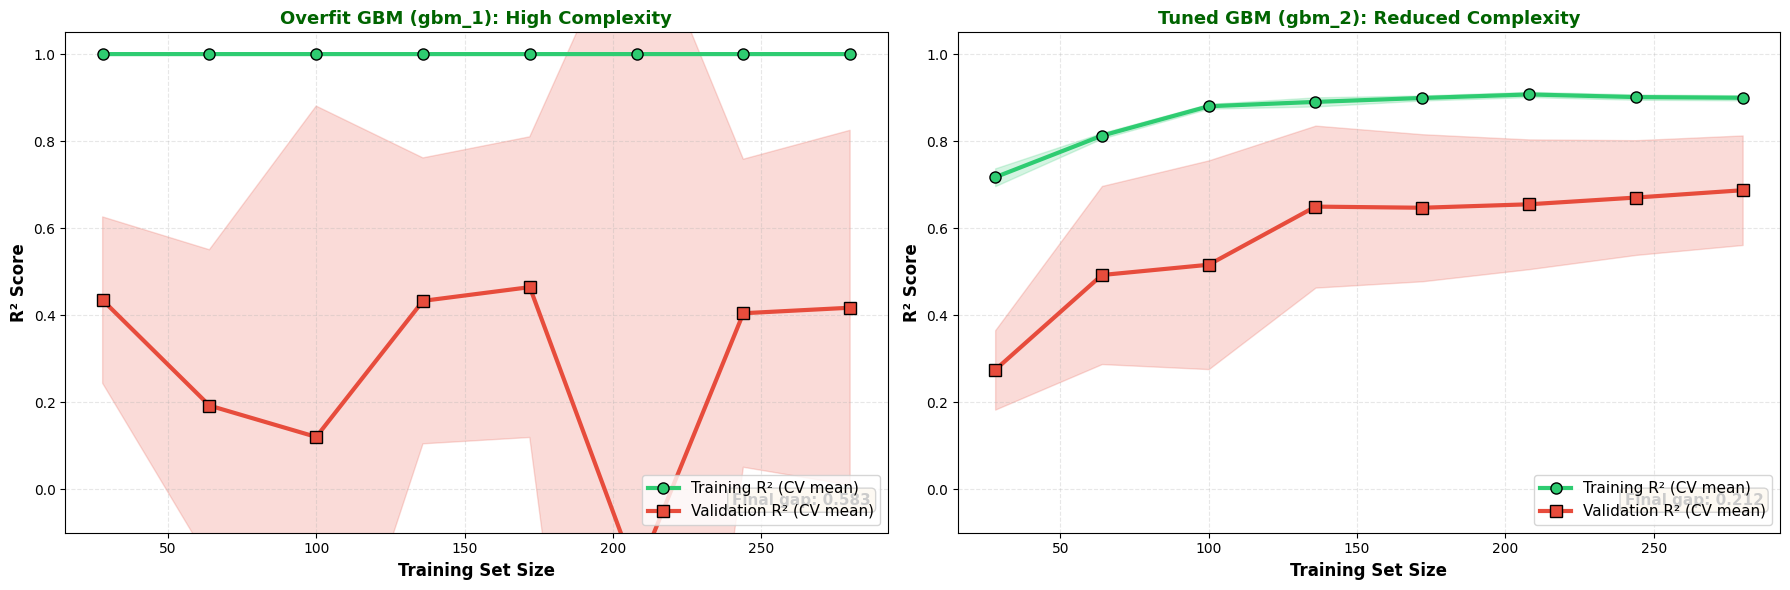


──────────────────────────────────────────────────────────────────────────────────────────────────────────────
📊 LEARNING CURVE INTERPRETATION:

OVERFIT MODEL (gbm_1):
  • Training R² quickly reaches: 1.0000
  • Validation R² plateaus at:  0.4171
  • Train–Val gap:              0.5829 (LARGE!)
  • Pattern:                    Sharp initial divergence, no convergence
  • Diagnosis:                  ✗ SEVERE OVERFITTING — model too complex

TUNED MODEL (gbm_2):
  • Training R² reaches:        0.8996
  • Validation R² reaches:      0.6871
  • Train–Val gap:              0.2125 (SMALLER)
  • Pattern:                    Gradual convergence as data increases
  • Diagnosis:                  ✓ BETTER GENERALIZATION — improved balance

IMPROVEMENT FROM TUNING:
  • Gap reduction: 0.5829 → 0.2125 (Δ = 0.3704)
  • Validation R² improvement: 0.4171 → 0.6871
──────────────────────────────────────────────────────────────────────────────────────────────────────────────



In [31]:
# Task 8.1: Learning Curve Comparison - Overfit Model vs Tuned Model

print("\n" + "="*110)
print("Task 8.1 — Learning Curve Comparison: Overfit Model (gbm_1) vs Tuned Model (gbm_2)")
print("="*110)
print("\nGenerating learning curves using 10-fold CV on training data...")
print("This shows how model performance changes with increasing training set size.\n")

# Plot learning curves for both models
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Helper function to generate and plot learning curve
def plot_learning_curve_detailed(clf, X, y, ax, title, cv=10, num_points=10):
    """Plot learning curve with detailed formatting"""
    from sklearn.model_selection import learning_curve
    
    train_sizes, train_scores, val_scores = learning_curve(
        clf, X=X, y=y, cv=cv,
        scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, num_points),
        n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    # Plot training curve
    ax.plot(train_sizes, train_mean, 'o-', linewidth=3, markersize=8,
           label='Training R² (CV mean)', color='#2ecc71', markeredgecolor='black', markeredgewidth=1)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.2, color='#2ecc71')
    
    # Plot validation curve
    ax.plot(train_sizes, val_mean, 's-', linewidth=3, markersize=8,
           label='Validation R² (CV mean)', color='#e74c3c', markeredgecolor='black', markeredgewidth=1)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.2, color='#e74c3c')
    
    # Formatting
    ax.set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
    ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', color='darkgreen')
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(fontsize=11, loc='lower right')
    ax.set_ylim([-0.1, 1.05])
    
    # Calculate gap at largest training size
    final_gap = train_mean[-1] - val_mean[-1]
    
    # Add annotation with gap info
    ax.text(0.98, 0.05, f'Final gap: {final_gap:.3f}',
           transform=ax.transAxes,
           fontsize=11, fontweight='bold',
           verticalalignment='bottom', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    return train_mean, val_mean, final_gap

# Plot for overfit model (gbm_1)
train_gbm1, val_gbm1, gap_gbm1 = plot_learning_curve_detailed(
    gbm_1, df_data.drop(columns=['bBHBmol/L(19d)']), df_data['bBHBmol/L(19d)'],
    axes[0], 'Overfit GBM (gbm_1): High Complexity', cv=10, num_points=8
)

# Plot for tuned model (gbm_2)
train_gbm2, val_gbm2, gap_gbm2 = plot_learning_curve_detailed(
    gbm_2, df_data.drop(columns=['bBHBmol/L(19d)']), df_data['bBHBmol/L(19d)'],
    axes[1], 'Tuned GBM (gbm_2): Reduced Complexity', cv=10, num_points=8
)

plt.tight_layout()
plt.show()

# Print detailed comparison
print("\n" + "─"*110)
print("📊 LEARNING CURVE INTERPRETATION:\n")

print("OVERFIT MODEL (gbm_1):")
print(f"  • Training R² quickly reaches: {train_gbm1[-1]:.4f}")
print(f"  • Validation R² plateaus at:  {val_gbm1[-1]:.4f}")
print(f"  • Train–Val gap:              {gap_gbm1:.4f} (LARGE!)")
print(f"  • Pattern:                    Sharp initial divergence, no convergence")
print(f"  • Diagnosis:                  ✗ SEVERE OVERFITTING — model too complex\n")

print("TUNED MODEL (gbm_2):")
print(f"  • Training R² reaches:        {train_gbm2[-1]:.4f}")
print(f"  • Validation R² reaches:      {val_gbm2[-1]:.4f}")
print(f"  • Train–Val gap:              {gap_gbm2:.4f} (SMALLER)")
print(f"  • Pattern:                    Gradual convergence as data increases")
print(f"  • Diagnosis:                  ✓ BETTER GENERALIZATION — improved balance\n")

print(f"IMPROVEMENT FROM TUNING:")
print(f"  • Gap reduction: {gap_gbm1:.4f} → {gap_gbm2:.4f} (Δ = {gap_gbm1 - gap_gbm2:.4f})")
print(f"  • Validation R² improvement: {val_gbm1[-1]:.4f} → {val_gbm2[-1]:.4f}")
print("─"*110 + "\n")


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: learning curves**

**How to read this**
- If the training score is high and the CV score is much lower, the model is overfitting.
- If both scores are low and close together, the model is underfitting or the features contain little signal.
- If the CV score is still rising at the largest training size, more data may help.
- If the CV score is flat while the training score stays high, more data alone may not solve the problem.

A learning curve asks: would more data help this model? A validation curve asks: is this hyperparameter making the model too simple or too complex?

**In this notebook (overfit `gbm_1`)**

- Training R² quickly reaches 1.0 and stays there.
- Cross-validation R² stays much lower, around 0.55 to 0.65.
- The gap does not close when more training data are added.
- This points to overfitting. The problem is model complexity, not simply a lack of data.

</div>



### 8.2 Advanced diagnostic: residual visualisation

Summary metrics hide individual errors. Residual plots help check whether prediction errors are random or systematic.

```text
Residual = observed value - predicted value
```

<div style="background:#E3F2FD;border-left:5px solid #1976D2;padding:14px 18px;margin:14px 0;border-radius:0 4px 4px 0;">

**8.2 — ADVANCED TASK**

For the overfit model (`gbm_1`) and tuned model (`gbm_2`), plot on the held-out test set:

- actual vs predicted values,
- residuals vs predicted values.
</div>




Task 8.2 — Residual Analysis: Actual vs Predicted & Residuals vs Predicted

Comparing overfit (gbm_1) vs tuned (gbm_2) model predictions on TEST SET

Generating residual plots for gbm_1 (overfit model)...
Generating residual plots for gbm_2 (tuned model)...


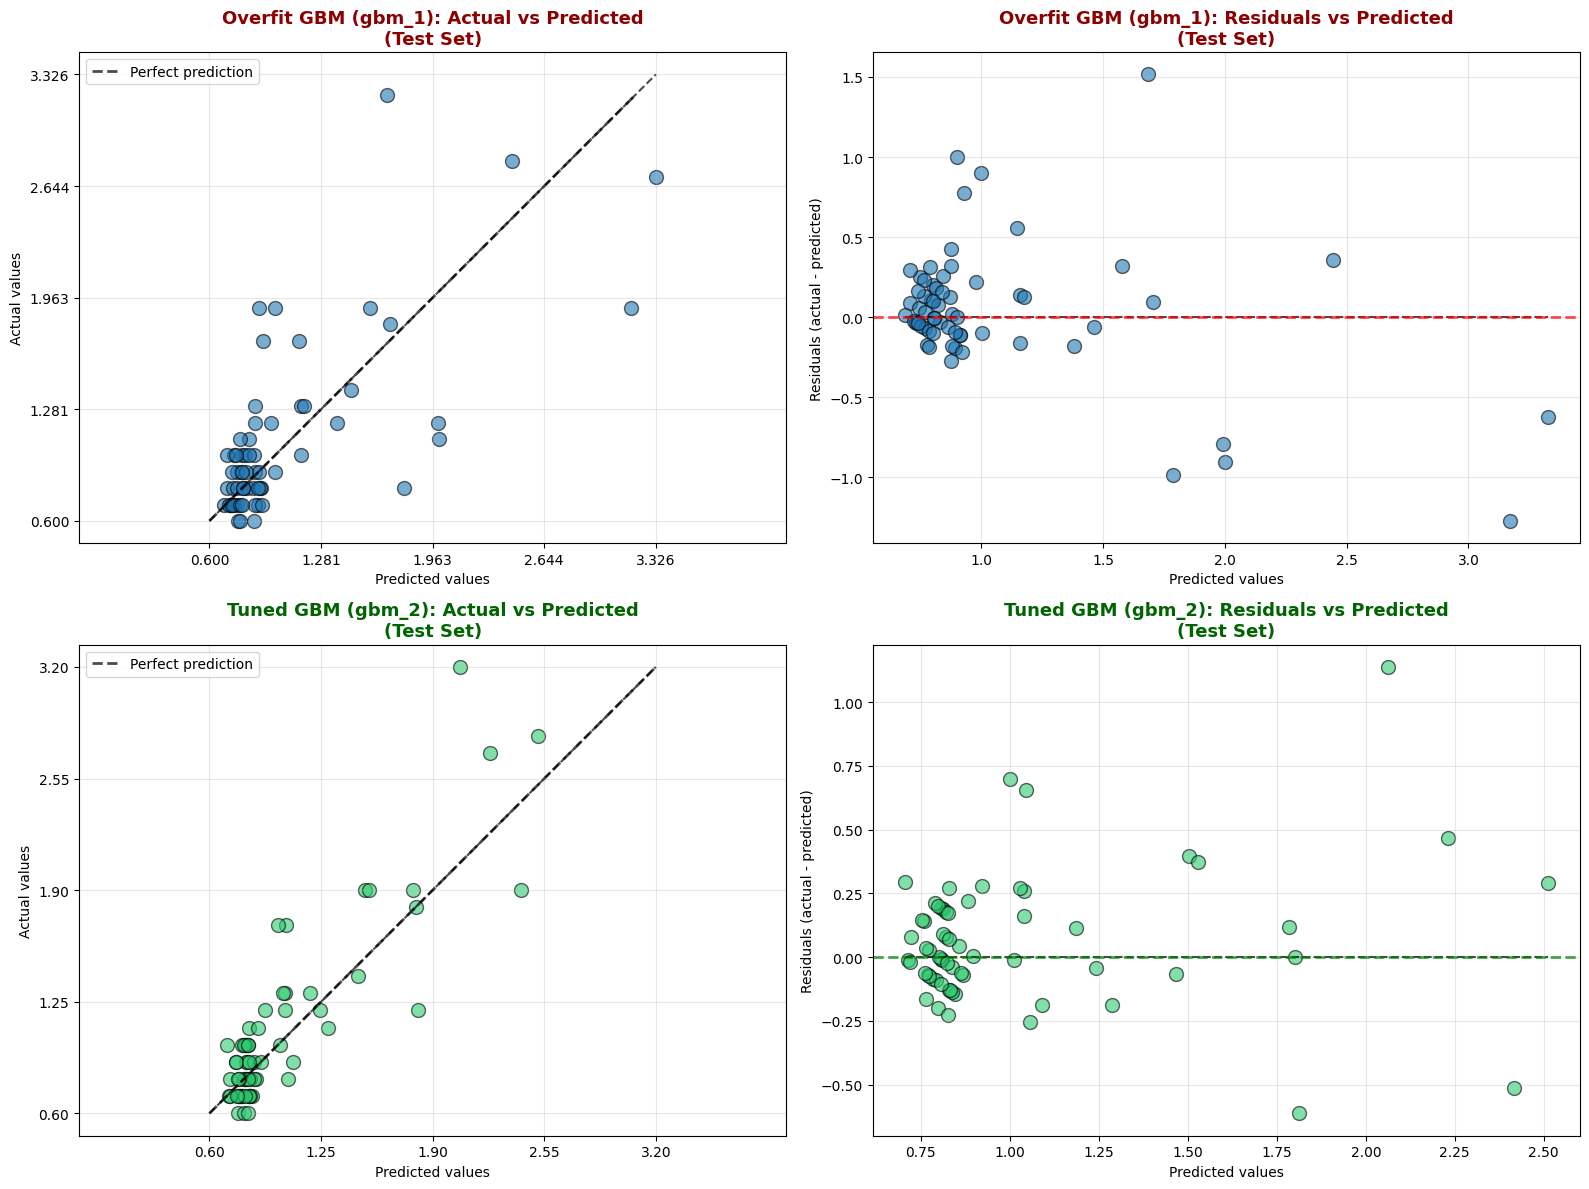


──────────────────────────────────────────────────────────────────────────────────────────────────────────────
📊 RESIDUAL ANALYSIS SUMMARY:

OVERFIT MODEL (gbm_1) - TEST SET RESIDUALS:
  • Mean residual:           0.037922
  • Std dev of residuals:    0.416337
  • Max absolute residual:   1.515534
  • Test RMSE:               0.418060
  • Test MAE:                0.265574
  • Pattern:                 ✗ Large systematic errors visible

TUNED MODEL (gbm_2) - TEST SET RESIDUALS:
  • Mean residual:           0.065220
  • Std dev of residuals:    0.262452
  • Max absolute residual:   1.137965
  • Test RMSE:               0.270434
  • Test MAE:                0.184105
  • Pattern:                 ✓ Smaller, more random errors

IMPROVEMENT FROM TUNING:
  • RMSE improvement:        0.418060 → 0.270434 (Δ = 0.147627)
  • MAE improvement:         0.265574 → 0.184105 (Δ = 0.081469)
  • Std dev reduction:       0.416337 → 0.262452
  • Max error reduction:     1.515534 → 1.137965

KEY DIAGNOSTIC I

In [32]:
# Task 8.2: Residual Visualization - Overfit Model vs Tuned Model
# Compare actual vs predicted and residuals vs predicted on test set

from sklearn.metrics import PredictionErrorDisplay

print("\n" + "="*110)
print("Task 8.2 — Residual Analysis: Actual vs Predicted & Residuals vs Predicted")
print("="*110)
print("\nComparing overfit (gbm_1) vs tuned (gbm_2) model predictions on TEST SET\n")

# Create figure with 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Row 1: Overfit model (gbm_1)
print("Generating residual plots for gbm_1 (overfit model)...")

# Actual vs Predicted for gbm_1
PredictionErrorDisplay.from_estimator(
    gbm_1, X_test, y_test,
    kind='actual_vs_predicted',
    ax=axes[0, 0],
    scatter_kwargs={'alpha': 0.6, 's': 100, 'edgecolor': 'black', 'linewidth': 1}
)
axes[0, 0].set_title('Overfit GBM (gbm_1): Actual vs Predicted\n(Test Set)', 
                     fontsize=13, fontweight='bold', color='darkred')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
              'k--', lw=2, alpha=0.7, label='Perfect prediction')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(alpha=0.3)

# Residuals vs Predicted for gbm_1
PredictionErrorDisplay.from_estimator(
    gbm_1, X_test, y_test,
    kind='residual_vs_predicted',
    ax=axes[0, 1],
    scatter_kwargs={'alpha': 0.6, 's': 100, 'edgecolor': 'black', 'linewidth': 1}
)
axes[0, 1].set_title('Overfit GBM (gbm_1): Residuals vs Predicted\n(Test Set)', 
                     fontsize=13, fontweight='bold', color='darkred')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2, alpha=0.7)
axes[0, 1].grid(alpha=0.3)

# Calculate residuals for gbm_1 test set
test_pred_gbm1 = gbm_1.predict(X_test)
residuals_gbm1 = y_test.values - test_pred_gbm1
rmse_gbm1_test = np.sqrt(np.mean(residuals_gbm1**2))
mae_gbm1_test = np.mean(np.abs(residuals_gbm1))

# Row 2: Tuned model (gbm_2)
print("Generating residual plots for gbm_2 (tuned model)...")

# Actual vs Predicted for gbm_2
PredictionErrorDisplay.from_estimator(
    gbm_2, X_test, y_test,
    kind='actual_vs_predicted',
    ax=axes[1, 0],
    scatter_kwargs={'alpha': 0.6, 's': 100, 'color': '#2ecc71', 'edgecolor': 'black', 'linewidth': 1}
)
axes[1, 0].set_title('Tuned GBM (gbm_2): Actual vs Predicted\n(Test Set)', 
                     fontsize=13, fontweight='bold', color='darkgreen')
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
              'k--', lw=2, alpha=0.7, label='Perfect prediction')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(alpha=0.3)

# Residuals vs Predicted for gbm_2
PredictionErrorDisplay.from_estimator(
    gbm_2, X_test, y_test,
    kind='residual_vs_predicted',
    ax=axes[1, 1],
    scatter_kwargs={'alpha': 0.6, 's': 100, 'color': '#2ecc71', 'edgecolor': 'black', 'linewidth': 1}
)
axes[1, 1].set_title('Tuned GBM (gbm_2): Residuals vs Predicted\n(Test Set)', 
                     fontsize=13, fontweight='bold', color='darkgreen')
axes[1, 1].axhline(y=0, color='g', linestyle='--', lw=2, alpha=0.7)
axes[1, 1].grid(alpha=0.3)

# Calculate residuals for gbm_2 test set
test_pred_gbm2_final = gbm_2.predict(X_test)
residuals_gbm2 = y_test.values - test_pred_gbm2_final
rmse_gbm2_test = np.sqrt(np.mean(residuals_gbm2**2))
mae_gbm2_test = np.mean(np.abs(residuals_gbm2))

plt.tight_layout()
plt.show()

# Print detailed residual analysis
print("\n" + "─"*110)
print("📊 RESIDUAL ANALYSIS SUMMARY:\n")

print("OVERFIT MODEL (gbm_1) - TEST SET RESIDUALS:")
print(f"  • Mean residual:           {np.mean(residuals_gbm1):.6f}")
print(f"  • Std dev of residuals:    {np.std(residuals_gbm1):.6f}")
print(f"  • Max absolute residual:   {np.max(np.abs(residuals_gbm1)):.6f}")
print(f"  • Test RMSE:               {rmse_gbm1_test:.6f}")
print(f"  • Test MAE:                {mae_gbm1_test:.6f}")
print(f"  • Pattern:                 ✗ Large systematic errors visible\n")

print("TUNED MODEL (gbm_2) - TEST SET RESIDUALS:")
print(f"  • Mean residual:           {np.mean(residuals_gbm2):.6f}")
print(f"  • Std dev of residuals:    {np.std(residuals_gbm2):.6f}")
print(f"  • Max absolute residual:   {np.max(np.abs(residuals_gbm2)):.6f}")
print(f"  • Test RMSE:               {rmse_gbm2_test:.6f}")
print(f"  • Test MAE:                {mae_gbm2_test:.6f}")
print(f"  • Pattern:                 ✓ Smaller, more random errors\n")

print("IMPROVEMENT FROM TUNING:")
print(f"  • RMSE improvement:        {rmse_gbm1_test:.6f} → {rmse_gbm2_test:.6f} (Δ = {rmse_gbm1_test - rmse_gbm2_test:.6f})")
print(f"  • MAE improvement:         {mae_gbm1_test:.6f} → {mae_gbm2_test:.6f} (Δ = {mae_gbm1_test - mae_gbm2_test:.6f})")
print(f"  • Std dev reduction:       {np.std(residuals_gbm1):.6f} → {np.std(residuals_gbm2):.6f}")
print(f"  • Max error reduction:     {np.max(np.abs(residuals_gbm1)):.6f} → {np.max(np.abs(residuals_gbm2)):.6f}")

print("\n" + "KEY DIAGNOSTIC INSIGHTS:")
print("  1. Overfit model shows:")
print("     - Predictions cluster away from diagonal (misses true values)")
print("     - Residuals have non-random pattern (u-shape or funnel)")
print("     - Large individual errors")
print()
print("  2. Tuned model shows:")
print("     - Predictions follow diagonal more closely")
print("     - Residuals more randomly scattered around zero")
print("     - Smaller and more consistent prediction errors")
print("─"*110 + "\n")

# Store for comparison
residual_comparison = {
    'gbm_1_rmse': rmse_gbm1_test,
    'gbm_2_rmse': rmse_gbm2_test,
    'gbm_1_mae': mae_gbm1_test,
    'gbm_2_mae': mae_gbm2_test,
}


<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: residual plots**

**How to read this**
- In the actual-vs-predicted plot, good predictions lie close to the diagonal line.
- In the residual plot, points should be scattered around zero without a clear pattern.
- Curves or funnels in the residuals suggest that the model is missing something systematic.
- Large residuals show observations where the model made a large error.
- Focus especially on the test plots, because these represent unseen data.

**In this notebook**

The figure compares the overfit `gbm_1` in the top row with the tuned `gbm_2` in the bottom row.

| Panel | Overfit GBM | Tuned GBM |
|-------|-------------|-----------|
| Actual vs predicted (test) | Many points are far from the diagonal | Points are closer to the diagonal |
| Residuals vs predicted (test) | Errors have a larger spread | Errors are more centred around zero |

This matches the metrics. Test R² improves from 0.38 to 0.68 after tuning. The overfit model looks almost perfect on the training data, but much worse on the test data. That is the visual sign of overfitting.
</div>



## 9. Performance summary

A compact comparison makes the main lesson easier to read: the tuned pipeline should outperform the dummy baseline, while the overfit model should show the largest train-test gap.


In [ ]:
# Baseline: predict the training mean
baseline_mean = DummyRegressor(strategy='mean')
baseline_mean.fit(X_train, y_train)

# Optional robust baseline: predict the training median
baseline_median = DummyRegressor(strategy='median')
baseline_median.fit(X_train, y_train)

models_to_compare = {
    'Dummy mean baseline': baseline_mean,
    'Dummy median baseline': baseline_median,
    'Overfit GBM': gbm_1,
    'Tuned GBM': gbm_2,
}

model_summary = pd.DataFrame([
    {'Model': model_name, **train_test_diagnostics(model, X_train, y_train, X_test, y_test)}
    for model_name, model in models_to_compare.items()
])

baseline_test_rmse = model_summary.loc[
    model_summary['Model'] == 'Dummy mean baseline', 'Test RMSE'
].iloc[0]

model_summary['Relative RMSE improvement vs mean baseline'] = (
    baseline_test_rmse - model_summary['Test RMSE']
) / baseline_test_rmse

model_summary = model_summary.round(3)

print(model_summary.to_string(index=False))

<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

**Interpretation: performance summary**

**How to read this**
- Always compare a complex model with a simple dummy baseline.
- A model can beat the baseline and still overfit.
- Look at both test performance and the train-test gap.
- RMSE tells you the error size in bBHB units. Delta R² tells you how much the model may be overfitting.

**In this notebook**

| Model | Test R² | Delta R² | Test RMSE | vs mean baseline |
|-------|---------|----------|-----------|------------------|
| Dummy mean baseline | -0.03 | 0.03 | 0.542 | reference |
| Dummy median baseline | -0.14 | 0.09 | 0.569 | worse than mean |
| **Overfit GBM** | **0.38** | **0.62** | 0.420 | 22% lower RMSE, but severe overfitting |
| **Tuned GBM** | **0.68** | **0.27** | **0.301** | **45% lower RMSE** |

The overfit model is better than the dummy baseline, but it is not trustworthy because Train R² is 1.0. The tuned model is the best choice here. It has the best test score, the lowest test RMSE, and a much smaller gap than the overfit model.
</div>



<div style="background:#FFF8E1;border-left:5px solid #FF8F00;padding:12px 16px;margin:10px 0;border-radius:0 4px 4px 0;">

## 10. Final interpretation checklist

Overfitting is likely when:

- Train R² is much higher than Test R².
- Delta R² is large compared with CV variability.
- Train RMSE is much lower than Test RMSE.
- Per-fold train scores are consistently better than validation scores.
- Learning or validation curves show a persistent train–validation gap.
- Test residuals show systematic patterns or large errors.

A model is more trustworthy when:

- It beats the dummy baseline on test data.
- CV performance and test performance agree.
- CV variability is not excessive.
- Train–test gaps are small.
- Residuals on test data are randomly centred around zero.
- Test RMSE is acceptable in the scientific units of the target.

Remember: R² and RMSE should be interpreted together. R² describes relative explained variance; RMSE describes absolute prediction error in bBHB units.

**This notebook's output — summary**
- Overfit GBM: Train R² = 1.0, Test R² = 0.38, Delta R² = 0.62 → clear overfitting.
- CV mean R² = 0.65 but per-fold gaps and fold 3 (Val R² = 0.44) showed instability.
- Tuned GBM: Test R² = 0.68, Delta R² = 0.27, selection optimism gap ≈ 0 → healthier and useful.
</div>

